# Analisis espacial: Conexion Social vs. pobreza multidimensional (EMB)

**Equipo Conexion Social - Bogota me conecta | Bogota Datajam 2026**

## Objetivo

Este notebook responde la pregunta de analisis del equipo:

> ¿Las instalaciones del programa Conexion Social estan llegando efectivamente a las
> zonas de Bogota con mayores niveles de pobreza multidimensional?

Se compara el numero de **hogares instalados** por el programa Conexion Social
(fuente interna SDIS, `Perfiles_CS.xlsx`) contra el **Indice de Pobreza
Multidimensional (IPM)** estimado con la **Encuesta Multiproposito de Bogota (EMB) 2021**
y contra la **matricula oficial SIMAT** (`Simat_1Jul26.csv`), desagregando por:

1. **Localidad** (20 localidades urbanas) - desagregacion robusta, 1 a 1 con la EMB y con SIMAT.
2. **UPZ** (Unidad de Planeamiento Zonal) - desagregacion intermedia. La EMB publica sus
   estimaciones por **grupos de UPZ** (varias UPZ pequeñas agregadas por tamaño de muestra),
   por lo que se construye una tabla de correspondencia UPZ individual -> grupo de UPZ,
   reutilizada tanto para Conexion Social como para SIMAT.
3. **Sector catastral** - solo de forma descriptiva para las instalaciones de Conexion
   Social, ya que ni la EMB ni SIMAT tienen esa desagregacion (ver nota de limitacion
   en la seccion 6).

La seccion 8 agrega SIMAT (numero de estudiantes por colegio/localidad/UPZ) y la
seccion 9 compara conjuntamente las tres fuentes -- pobreza, Conexion Social y
matricula oficial.

## Fuentes de datos

| Fuente | Archivo | Nivel | Sensibilidad |
|---|---|---|---|
| Instalaciones Conexion Social | `Perfiles_CS.xlsx` | Hogar (con direccion y coordenadas) | **Sensible** - no se sube a GitHub |
| Encuesta Multiproposito 2021 | `em2021.csv` | Persona/hogar (microdato) | **Sensible** - no se sube a GitHub |
| Variables adicionales EMB (IPM) | `20240430_variables_adicionales_2021.csv` | Hogar/persona | **Sensible** - no se sube a GitHub |
| Matricula oficial SIMAT | `Simat_1Jul26.csv` | Estudiante (nombre, documento, direccion, etc.) | **Muy sensible** - no se sube a GitHub, no se leen columnas personales |
| Limites de Localidad | Datos Abiertos Bogota / IDECA (ArcGIS REST) | Poligono | Publica |
| Limites de UPZ | Datos Abiertos Bogota / IDECA (ArcGIS REST) | Poligono | Publica |
| Limites de Sector Catastral | Datos Abiertos Bogota / IDECA (ArcGIS REST) | Poligono | Publica |

Los archivos originales con datos personales (direcciones, coordenadas exactas de
hogares, microdatos EMB, microdato SIMAT) **permanecen solo en este computador** (ver
`.gitignore`). Al repositorio de GitHub solo se suben este notebook y los resultados
**agregados** por localidad / UPZ / sector catastral / colegio (sin informacion
individual, salvo los mapas de puntos de la seccion 6.3 que se documentan aparte).


## 1. Configuracion

In [1]:
import json
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from shapely.geometry import Point

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110


def normalizar(texto: str) -> str:
    # Normaliza nombres geograficos para poder cruzar entre fuentes que usan
    # mayusculas/tildes distintas (ej. "Ciudad Bolivar" vs "CIUDAD BOLIVAR").
    texto = str(texto).upper().strip()
    texto = "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")
    return texto


# Rutas del proyecto (este notebook vive en DataJam/notebooks/)
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR
GEO_DIR = BASE_DIR / "data" / "geo"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUT_TABLES = BASE_DIR / "outputs" / "tables"
OUT_FIGS = BASE_DIR / "outputs" / "figures"

for d in (GEO_DIR, PROCESSED_DIR, OUT_TABLES, OUT_FIGS):
    d.mkdir(parents=True, exist_ok=True)

print("Carpeta base del proyecto:", BASE_DIR)


Carpeta base del proyecto: C:\Users\Lenovo\Documents\JSEH\SDIS\DataJam


## 2. Poligonos geograficos oficiales (localidad, UPZ, sector catastral)

Se descargan de los servicios geograficos publicos de Catastro Bogota / IDECA
(`serviciosgis.catastrobogota.gov.co`), publicados tambien en el Portal de Datos
Abiertos de Bogota (https://datosabiertos.bogota.gov.co). Se guardan en
`data/geo/*.geojson` para no depender de internet en corridas futuras y para poder
versionar estos limites (son informacion publica, no sensible) en el repositorio.

Nota cartografica: Sumapaz (la unica localidad rural de Bogota) se excluye de los
**mapas** por su enorme extension relativa frente a las 19 localidades urbanas, lo que
aplastaria visualmente el resto de la ciudad. Las **tablas** si conservan a Sumapaz.


In [2]:
ARCGIS_LAYERS = {
    "localidad": "https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/localidad/MapServer/0",
    "upz": "https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/unidadplaneamientozonal/MapServer/0",
    "sector_catastral": "https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/catastro/sectorcatastral/MapServer/0",
}


def descargar_capa_arcgis(url_layer: str, page_size: int = 1000) -> gpd.GeoDataFrame:
    # Descarga todos los registros de una capa ArcGIS REST como GeoDataFrame (EPSG:4326)
    features = []
    offset = 0
    while True:
        params = {
            "where": "1=1",
            "outFields": "*",
            "f": "geojson",
            "outSR": 4326,
            "resultOffset": offset,
            "resultRecordCount": page_size,
        }
        r = requests.get(f"{url_layer}/query", params=params, timeout=60)
        r.raise_for_status()
        chunk = r.json().get("features", [])
        if not chunk:
            break
        features.extend(chunk)
        if len(chunk) < page_size:
            break
        offset += page_size
    return gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")


def cargar_capa(nombre: str) -> gpd.GeoDataFrame:
    ruta = GEO_DIR / f"{nombre}.geojson"
    if ruta.exists():
        return gpd.read_file(ruta)
    gdf = descargar_capa_arcgis(ARCGIS_LAYERS[nombre])
    gdf.to_file(ruta, driver="GeoJSON")
    return gdf


gdf_localidad = cargar_capa("localidad")
gdf_upz = cargar_capa("upz")
gdf_sector = cargar_capa("sector_catastral")

# Llave normalizada para poder cruzar contra otras fuentes (EMB, Perfiles_CS)
# que no necesariamente usan las mismas mayusculas/tildes.
gdf_localidad["LOC_KEY"] = gdf_localidad["LOCNOMBRE"].apply(normalizar)

# Sumapaz es la unica localidad rural de Bogota: su area es varias veces mayor que
# las 19 localidades urbanas juntas y el programa Conexion Social (fibra optica
# urbana) practicamente no tiene presencia alli. Se excluye SOLO de los mapas para
# que la variacion en la zona urbana sea visible; las tablas si la conservan.
gdf_localidad_urbano = gdf_localidad[gdf_localidad["LOC_KEY"] != "SUMAPAZ"].copy()
area_urbana_union = gdf_localidad_urbano.union_all()

print("Localidades:", len(gdf_localidad))
print("UPZ:", len(gdf_upz))
print("Sectores catastrales:", len(gdf_sector))
gdf_localidad.head(3)


Localidades: 20
UPZ: 112
Sectores catastrales: 1230


,OBJECTID,LOCNOMBRE,LOCAADMINI,LOCAREA,LOCCODIGO,SHAPE.AREA,SHAPE.LEN,geometry,LOC_KEY
0,1,ANTONIO NARIÑO,Acuerdo 117 de 2003,4.879543e+06,15,0.000397,0.108973,"POLYGON ((-74.13075 4.59335, -74.13075 4.59335...",ANTONIO NARINO
1,2,TUNJUELITO,Acuerdo 117 de 2003,9.910940e+06,06,0.000807,0.210542,"POLYGON ((-74.13777 4.59489, -74.14043 4.59536...",TUNJUELITO
2,3,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1.383408e+07,18,0.001126,0.174513,"POLYGON ((-74.12803 4.59254, -74.12829 4.59265...",RAFAEL URIBE URIBE


## 3. Hogares instalados de Conexion Social (`Perfiles_CS.xlsx`)

Version actualizada del archivo (corte 2 de julio de 2026). Ahora trae la columna
`Localidad` directamente del sistema fuente -- ya no se infiere por coordenadas -- y
tambien `COORD_X_AUTO_REC` / `COORD_Y_AUTO_REC`, que se usan para derivar UPZ y sector
catastral por union espacial (esas dos no vienen en el archivo).

**Verificacion de calidad:** se compara la `Localidad` declarada contra la localidad
que resulta de ubicar la coordenada del hogar dentro de los poligonos oficiales. Los
hogares donde no coinciden -- o que no tienen coordenadas -- se separan en un Excel
para que el equipo los revise (seccion 3.1) y **no entran en el mapa de puntos**
(secciones 6.3 y 8.3). Si siguen contando en las cifras generales y en las tablas por
localidad, porque la `Localidad` declarada es el dato mas confiable que tenemos de
donde esta cada hogar, tenga o no coordenadas exactas.


In [3]:
df_cs = pd.read_excel(DATA_DIR / "Perfiles_CS.xlsx")
print("Hogares instalados Conexion Social (total, cifra general):", len(df_cs))


def normalizar_sisben(codigo: str) -> str:
    # El archivo mezcla codigos con y sin cero a la izquierda para el mismo grupo
    # (ej. "B6" y "B06" son la misma clasificacion Sisben).
    codigo = str(codigo).strip().upper()
    return f"{codigo[0]}{int(codigo[1:]):02d}"


df_cs["CLASIFICACION_SISBEN"] = df_cs["CLASIFICACION SISBEN"].apply(normalizar_sisben)
df_cs["LOC_KEY"] = df_cs["Localidad"].apply(normalizar)

LOCALIDADES_ABIERTAS = sorted(df_cs["Localidad"].unique())
print(f"Localidades con hogares instalados segun el campo 'Localidad': {len(LOCALIDADES_ABIERTAS)}")
print(LOCALIDADES_ABIERTAS)

# OJO: no se muestra el detalle de filas individuales (trae DIRECCION y coordenadas
# exactas por hogar). Este notebook se sube a un repositorio publico, asi que solo se
# despliegan columnas no identificables a modo de vista previa de la estructura.
df_cs[["Localidad", "TIP_ESTRATO_ENERGIA", "CLASIFICACION_SISBEN"]].head(3)


Hogares instalados Conexion Social (total, cifra general): 72797
Localidades con hogares instalados segun el campo 'Localidad': 9
['BOSA', 'CIUDAD BOLIVAR', 'ENGATIVA', 'KENNEDY', 'RAFAEL URIBE URIBE', 'SAN CRISTOBAL', 'SANTA FE', 'SUBA', 'TUNJUELITO']


,Localidad,TIP_ESTRATO_ENERGIA,CLASIFICACION_SISBEN
0,SUBA,2,B02
1,BOSA,2,C08
2,SUBA,2,C03


In [4]:
# Subconjunto geocodificado: solo estos hogares pueden ubicarse en el mapa o
# cruzarse contra UPZ / sector catastral (necesitan coordenadas).
sin_coordenadas = df_cs["COORD_X_AUTO_REC"].isna() | df_cs["COORD_Y_AUTO_REC"].isna()
print(f"Hogares sin coordenadas: {sin_coordenadas.sum()} de {len(df_cs)}")

df_geo = df_cs.loc[~sin_coordenadas].copy()
geometry = [Point(lon, lat) for lat, lon in zip(df_geo["COORD_X_AUTO_REC"], df_geo["COORD_Y_AUTO_REC"])]
gdf_cs = gpd.GeoDataFrame(df_geo, geometry=geometry, crs="EPSG:4326")

# Localidad geometrica (para verificar la declarada), UPZ y sector catastral: las tres
# se derivan ubicando la coordenada dentro de los poligonos oficiales.
gdf_cs = gpd.sjoin(
    gdf_cs,
    gdf_localidad[["LOCNOMBRE", "geometry"]].rename(columns={"LOCNOMBRE": "LOCALIDAD_GEOM"}),
    how="left", predicate="within",
).drop(columns="index_right")
gdf_cs = gpd.sjoin(
    gdf_cs, gdf_upz[["NOMBRE", "geometry"]].rename(columns={"NOMBRE": "UPZNombre"}),
    how="left", predicate="within",
).drop(columns="index_right")
gdf_cs = gpd.sjoin(
    gdf_cs, gdf_sector[["SCANOMBRE", "geometry"]].rename(columns={"SCANOMBRE": "SCaNombre"}),
    how="left", predicate="within",
).drop(columns="index_right")

sin_localidad_geom = gdf_cs["LOCALIDAD_GEOM"].isna()
if sin_localidad_geom.any():
    cercano = gpd.sjoin_nearest(
        gdf_cs.loc[sin_localidad_geom, ["geometry"]],
        gdf_localidad[["LOCNOMBRE", "geometry"]].rename(columns={"LOCNOMBRE": "LOCALIDAD_GEOM"}),
        how="left",
    )
    gdf_cs.loc[sin_localidad_geom, "LOCALIDAD_GEOM"] = cercano["LOCALIDAD_GEOM"].values

gdf_cs["MISMATCH_LOCALIDAD"] = gdf_cs["Localidad"] != gdf_cs["LOCALIDAD_GEOM"]
print(f"Localidad declarada coincide con la geometrica: {(~gdf_cs['MISMATCH_LOCALIDAD']).mean() * 100:.2f}%")
print(f"Hogares con desajuste geografico (para revisar): {gdf_cs['MISMATCH_LOCALIDAD'].sum()}")

gdf_cs_verificados = gdf_cs.loc[~gdf_cs["MISMATCH_LOCALIDAD"]].copy()


Hogares sin coordenadas: 124 de 72797


Localidad declarada coincide con la geometrica: 99.91%
Hogares con desajuste geografico (para revisar): 68


### 3.1 Excel de revision para el equipo

Junta los hogares con desajuste geografico (declarado ≠ geometrico) y los que no
tienen coordenadas, en un solo archivo para que el equipo los revise. **Este archivo
tiene direccion y coordenadas exactas — se guarda solo en este computador, nunca se
sube a GitHub** (ver `.gitignore`).


In [5]:
revision = pd.concat([
    gdf_cs.loc[gdf_cs["MISMATCH_LOCALIDAD"],
               ["LLAVE_HOG", "DIRECCIÓN", "Barrio", "Localidad", "LOCALIDAD_GEOM",
                "COORD_X_AUTO_REC", "COORD_Y_AUTO_REC"]]
          .assign(motivo="Localidad declarada no coincide con la ubicacion"),
    df_cs.loc[sin_coordenadas, ["LLAVE_HOG", "DIRECCIÓN", "Barrio", "Localidad"]]
         .assign(LOCALIDAD_GEOM="(sin coordenadas)", motivo="Sin coordenadas"),
], ignore_index=True)
revision = revision.rename(columns={"Localidad": "localidad_declarada", "LOCALIDAD_GEOM": "localidad_geometrica"})

ruta_revision = DATA_DIR / "revision_equipo_hogares_localidad.xlsx"
revision.to_excel(ruta_revision, index=False)
print(f"Hogares para que el equipo revise: {len(revision)} -> {ruta_revision.name}")
revision["motivo"].value_counts()


Hogares para que el equipo revise: 192 -> revision_equipo_hogares_localidad.xlsx


motivo
Sin coordenadas                                     124
Localidad declarada no coincide con la ubicacion     68
Name: count, dtype: int64

## 4. Pobreza multidimensional (EMB 2021)

`em2021.csv` es un archivo ancho (1 fila por persona, ~1550 columnas, codificacion
`latin-1`) que junta los modulos de vivienda/hogar/persona/ingresos de la encuesta.
`20240430_variables_adicionales_2021.csv` trae variables derivadas ya calculadas,
entre ellas `N_pobre_ipm` (hogar pobre por IPM = 1/0). Se usa el motor `pyarrow` de
pandas por la robustez y velocidad frente a un archivo de ~1.2 GB.

Metodologia de agregacion: el IPM se mide a nivel de **hogar**, por lo que se
deduplica a nivel de `DIRECTORIO_HOG` y se pondera con el factor de expansion
`FEX_C` (cada hogar de la muestra representa `FEX_C` hogares de la poblacion) para
obtener una tasa de pobreza representativa de la ciudad, no solo de la muestra.


In [6]:
COLS_GEO = ["DIRECTORIO", "DIRECTORIO_HOG", "COD_LOCALIDAD", "NOMBRE_LOCALIDAD",
            "COD_UPZ_GRUPO", "NOMBRE_UPZ_GRUPO", "ESTRATO2021", "FEX_C"]

cache_geo = PROCESSED_DIR / "em2021_geo.parquet"
if cache_geo.exists():
    em_geo = pd.read_parquet(cache_geo)
else:
    em_geo = pd.read_csv(DATA_DIR / "em2021.csv", encoding="latin1",
                          usecols=COLS_GEO, engine="pyarrow")
    em_geo.to_parquet(cache_geo)

em_geo_hog = em_geo.drop_duplicates("DIRECTORIO_HOG")
print("Hogares unicos en la EMB 2021:", len(em_geo_hog))
em_geo_hog.head(3)


Hogares unicos en la EMB 2021: 107119


,DIRECTORIO,DIRECTORIO_HOG,COD_LOCALIDAD,NOMBRE_LOCALIDAD,COD_UPZ_GRUPO,NOMBRE_UPZ_GRUPO,ESTRATO2021,FEX_C
0,166238,1662381,2.0,Chapinero,NaN,NaN,11001202,1.698492
2,220102,2201021,19.0,Ciudad Bolívar,NaN,NaN,11001219,6.744412
6,220385,2203851,20.0,Sumapaz,NaN,NaN,11001220,1.804632


In [7]:
adicionales = pd.read_csv(
    DATA_DIR / "20240430_variables_adicionales_2021.csv", encoding="latin1",
    usecols=["directorio_hog", "N_pobre_ipm"],
).drop_duplicates("directorio_hog")

hogares_ipm = em_geo_hog.merge(
    adicionales, left_on="DIRECTORIO_HOG", right_on="directorio_hog", how="left",
)

sin_ipm = hogares_ipm["N_pobre_ipm"].isna().sum()
print(f"Hogares EMB sin dato de IPM tras el cruce: {sin_ipm} de {len(hogares_ipm)}")
hogares_ipm = hogares_ipm.dropna(subset=["N_pobre_ipm"])
hogares_ipm.to_parquet(PROCESSED_DIR / "hogares_ipm.parquet")
hogares_ipm[["NOMBRE_LOCALIDAD", "NOMBRE_UPZ_GRUPO", "FEX_C", "N_pobre_ipm"]].head(3)


Hogares EMB sin dato de IPM tras el cruce: 0 de 107119


,NOMBRE_LOCALIDAD,NOMBRE_UPZ_GRUPO,FEX_C,N_pobre_ipm
0,Chapinero,NaN,1.698492,1
1,Ciudad Bolívar,NaN,6.744412,0
2,Sumapaz,NaN,1.804632,0


In [8]:
def tasa_ipm_ponderada(g: pd.DataFrame) -> float:
    return float((g["N_pobre_ipm"] * g["FEX_C"]).sum() / g["FEX_C"].sum() * 100)


ipm_localidad = (
    hogares_ipm.groupby("NOMBRE_LOCALIDAD")
    .apply(tasa_ipm_ponderada, include_groups=False)
    .rename("pct_pobreza_ipm")
    .reset_index()
)
hogares_totales_localidad = (
    hogares_ipm.groupby("NOMBRE_LOCALIDAD")["FEX_C"].sum()
    .rename("hogares_totales_estimados_emb")
    .reset_index()
)
ipm_localidad = ipm_localidad.merge(hogares_totales_localidad, on="NOMBRE_LOCALIDAD")
ipm_localidad["LOC_KEY"] = ipm_localidad["NOMBRE_LOCALIDAD"].apply(normalizar)
ipm_localidad = ipm_localidad.sort_values("pct_pobreza_ipm", ascending=False)
ipm_localidad


,NOMBRE_LOCALIDAD,pct_pobreza_ipm,hogares_totales_estimados_emb,LOC_KEY
15,Sumapaz,15.580286,1135.113780,SUMAPAZ
19,Usme,10.226706,128688.921145,USME
4,Ciudad Bolívar,8.576726,208702.085748,CIUDAD BOLIVAR
13,Santa Fe,7.991648,39064.354319,SANTA FE
11,Rafael Uribe Uribe,6.667842,136687.354445,RAFAEL URIBE URIBE
2,Bosa,6.489109,233692.505621,BOSA
12,San Cristóbal,5.036779,135671.094960,SAN CRISTOBAL
9,Los Mártires,5.002996,33136.594637,LOS MARTIRES
8,La Candelaria,4.262378,7603.195214,LA CANDELARIA
17,Tunjuelito,3.845420,70431.856300,TUNJUELITO


### 4.1 Correspondencia UPZ individual -> grupo de UPZ de la EMB

La EMB no siempre publica cada UPZ por separado: cuando una UPZ es muy pequeña, la
agrupa con vecinas (ej. `"BARRIOS UNIDOS: Parque Salitre + Doce de Octubre"`). Como
`Perfiles_CS.xlsx` trae la UPZ individual (`UPZNombre`), se construye una tabla de
correspondencia automatica a partir de los nombres de `NOMBRE_UPZ_GRUPO`, tal como lo
identifica la nota tecnica del equipo: *"los codigos de UPZ y localidad difieren en
formato y nomenclatura entre entidades, lo que obliga a procesos manuales de
armonizacion previos al cruce"*.


In [9]:
grupos_upz = hogares_ipm["NOMBRE_UPZ_GRUPO"].dropna().unique()

crosswalk = {}
for grupo in grupos_upz:
    parte = grupo.split(":", 1)[-1] if ":" in grupo else grupo
    componentes = [normalizar(c) for c in parte.split("+")]
    for comp in componentes:
        crosswalk[comp] = grupo

gdf_cs["upz_norm"] = gdf_cs["UPZNombre"].apply(normalizar)
gdf_cs["NOMBRE_UPZ_GRUPO"] = gdf_cs["upz_norm"].map(crosswalk)

tasa_match = gdf_cs["NOMBRE_UPZ_GRUPO"].notna().mean() * 100
print(f"Hogares CS con UPZ emparejada a un grupo EMB: {tasa_match:.1f}%")
sin_upz = gdf_cs["UPZNombre"].isna().sum()
if sin_upz:
    print(f"Hogares sin UPZ geometrica (fuera de todos los poligonos de UPZ): {sin_upz}")
print("\nUPZ de Conexion Social SIN correspondencia en la EMB (revisar manualmente):")
print(sorted(gdf_cs.loc[gdf_cs['NOMBRE_UPZ_GRUPO'].isna(), 'UPZNombre'].dropna().unique()))


Hogares CS con UPZ emparejada a un grupo EMB: 99.9%
Hogares sin UPZ geometrica (fuera de todos los poligonos de UPZ): 2

UPZ de Conexion Social SIN correspondencia en la EMB (revisar manualmente):
['JARDIN BOTANICO', 'JERUSALEM']


In [10]:
ipm_upz = (
    hogares_ipm.groupby("NOMBRE_UPZ_GRUPO")
    .apply(tasa_ipm_ponderada, include_groups=False)
    .rename("pct_pobreza_ipm")
    .reset_index()
)
hogares_totales_upz = (
    hogares_ipm.groupby("NOMBRE_UPZ_GRUPO")["FEX_C"].sum()
    .rename("hogares_totales_estimados_emb")
    .reset_index()
)
ipm_upz = ipm_upz.merge(hogares_totales_upz, on="NOMBRE_UPZ_GRUPO")
ipm_upz.sort_values("pct_pobreza_ipm", ascending=False).head(10)


,NOMBRE_UPZ_GRUPO,pct_pobreza_ipm,hogares_totales_estimados_emb
88,USME: Alfonso López + Ciudad Usme,16.510320,25148.782425
42,La Flora,15.266510,6762.234654
54,Lourdes,14.072589,13755.443256
12,CIUDAD BOLÍVAR: Monteblanco + El Tesoro + El M...,13.000301,18859.672774
55,Lucero,10.618561,54244.144513
89,USME: Parque Entrenubes + Danubio,10.161630,18905.434955
72,San Isidro - Patios,10.089829,5746.487615
22,Diana Turbay,9.707758,26469.746768
56,Marco Fidel Suárez,9.461298,18328.179787
63,Patio Bonito,9.438808,45151.630743


In [11]:
# Se calcula aqui (temprano) porque los mapas de las secciones 6 y 8 lo necesitan
# a nivel de UPZ, no solo de localidad.
cs_por_grupo_upz = gdf_cs.groupby("NOMBRE_UPZ_GRUPO").size().rename("hogares_cs").reset_index()

cruce_upz = ipm_upz.merge(cs_por_grupo_upz, on="NOMBRE_UPZ_GRUPO", how="left")
cruce_upz["hogares_cs"] = cruce_upz["hogares_cs"].fillna(0)
cruce_upz["cobertura_cs_por_1000_hogares"] = (
    cruce_upz["hogares_cs"] / cruce_upz["hogares_totales_estimados_emb"] * 1000
)
cruce_upz = cruce_upz.sort_values("pct_pobreza_ipm", ascending=False)

# Poligonos de UPZ individuales (112), coloreables por su grupo EMB: los mapas de
# intensidad usan este detalle en vez de rellenar toda la localidad de un solo color,
# con el limite de localidad encima en linea gruesa para no perder esa referencia.
gdf_upz_choropleth = gdf_upz.copy()
gdf_upz_choropleth["upz_norm"] = gdf_upz_choropleth["NOMBRE"].apply(normalizar)
gdf_upz_choropleth["NOMBRE_UPZ_GRUPO"] = gdf_upz_choropleth["upz_norm"].map(crosswalk)
sin_grupo = gdf_upz_choropleth["NOMBRE_UPZ_GRUPO"].isna().sum()
print(f"UPZ oficiales sin grupo EMB emparejado (quedan en gris en los mapas): {sin_grupo} de {len(gdf_upz_choropleth)}")


UPZ oficiales sin grupo EMB emparejado (quedan en gris en los mapas): 3 de 112


## 5. Agregacion de hogares Conexion Social por nivel geografico

`cs_localidad` usa la **`Localidad` declarada** y el universo completo de hogares
(cifra general, con y sin coordenadas). `cs_upz` y `cs_sector` solo pueden salir del
subconjunto geocodificado, porque UPZ y sector catastral se derivan por geometria.


In [12]:
cs_localidad = (
    df_cs.rename(columns={"Localidad": "LOCNOMBRE"})
    .groupby(["LOCNOMBRE", "LOC_KEY"]).size().rename("hogares_cs").reset_index()
)
cs_upz = gdf_cs.groupby("UPZNombre").size().rename("hogares_cs").reset_index()
cs_sector = gdf_cs.groupby("SCaNombre").size().rename("hogares_cs").reset_index()

print("Localidades con instalaciones:", len(cs_localidad))
print("UPZ con instalaciones:", len(cs_upz))
print("Sectores catastrales con instalaciones:", len(cs_sector))
cs_localidad.sort_values("hogares_cs", ascending=False)


Localidades con instalaciones: 9
UPZ con instalaciones: 62
Sectores catastrales con instalaciones: 418


,LOCNOMBRE,LOC_KEY,hogares_cs
0,BOSA,BOSA,17905
7,SUBA,SUBA,13790
3,KENNEDY,KENNEDY,12790
5,SAN CRISTOBAL,SAN CRISTOBAL,9170
4,RAFAEL URIBE URIBE,RAFAEL URIBE URIBE,5760
1,CIUDAD BOLIVAR,CIUDAD BOLIVAR,4551
2,ENGATIVA,ENGATIVA,4531
8,TUNJUELITO,TUNJUELITO,3623
6,SANTA FE,SANTA FE,677


## 6. Cruce Conexion Social vs. pobreza multidimensional

Se compara, para cada localidad, el **numero de hogares instalados** y una **tasa de
cobertura** (hogares CS por cada 1.000 hogares estimados por la EMB) frente al
**% de pobreza multidimensional**. La tasa de cobertura es la comparacion mas justa,
porque localidades grandes pueden tener muchas instalaciones simplemente por tener mas
hogares, no por estar mejor focalizadas.

> **Lectura importante:** el programa opera por fases -- solo `LOCALIDADES_ABIERTAS`
> tiene instalaciones (seccion 3). Una localidad con cobertura 0 no necesariamente esta
> mal focalizada: puede que **todavia no se haya abierto** ahi. `Usme`, por ejemplo,
> tiene la segunda pobreza mas alta de la ciudad y cobertura 0 porque aun no esta en la
> fase actual del despliegue, no porque el programa la haya descartado. La
> correlacion de esta seccion mide asociacion en toda la ciudad; la seccion 6.1 la
> repite solo dentro de las localidades ya abiertas, que es la comparacion valida para
> evaluar que tan bien focalizado esta el despliegue actual.


In [13]:
cruce_localidad = ipm_localidad.merge(
    cs_localidad[["LOC_KEY", "hogares_cs"]],
    on="LOC_KEY", how="left",
)
cruce_localidad["hogares_cs"] = cruce_localidad["hogares_cs"].fillna(0)
cruce_localidad["cobertura_cs_por_1000_hogares"] = (
    cruce_localidad["hogares_cs"] / cruce_localidad["hogares_totales_estimados_emb"] * 1000
)
cruce_localidad = cruce_localidad.sort_values("pct_pobreza_ipm", ascending=False)

corr = cruce_localidad[["pct_pobreza_ipm", "cobertura_cs_por_1000_hogares"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion de Spearman (pobreza IPM vs. cobertura CS) por localidad: {corr:.2f}")
cruce_localidad


Correlacion de Spearman (pobreza IPM vs. cobertura CS) por localidad: 0.36


,NOMBRE_LOCALIDAD,pct_pobreza_ipm,hogares_totales_estimados_emb,LOC_KEY,hogares_cs,cobertura_cs_por_1000_hogares
0,Sumapaz,15.580286,1135.113780,SUMAPAZ,0.0,0.000000
1,Usme,10.226706,128688.921145,USME,0.0,0.000000
2,Ciudad Bolívar,8.576726,208702.085748,CIUDAD BOLIVAR,4551.0,21.806203
3,Santa Fe,7.991648,39064.354319,SANTA FE,677.0,17.330377
4,Rafael Uribe Uribe,6.667842,136687.354445,RAFAEL URIBE URIBE,5760.0,42.139963
5,Bosa,6.489109,233692.505621,BOSA,17905.0,76.617776
6,San Cristóbal,5.036779,135671.094960,SAN CRISTOBAL,9170.0,67.589931
7,Los Mártires,5.002996,33136.594637,LOS MARTIRES,0.0,0.000000
8,La Candelaria,4.262378,7603.195214,LA CANDELARIA,0.0,0.000000
9,Tunjuelito,3.845420,70431.856300,TUNJUELITO,3623.0,51.439791


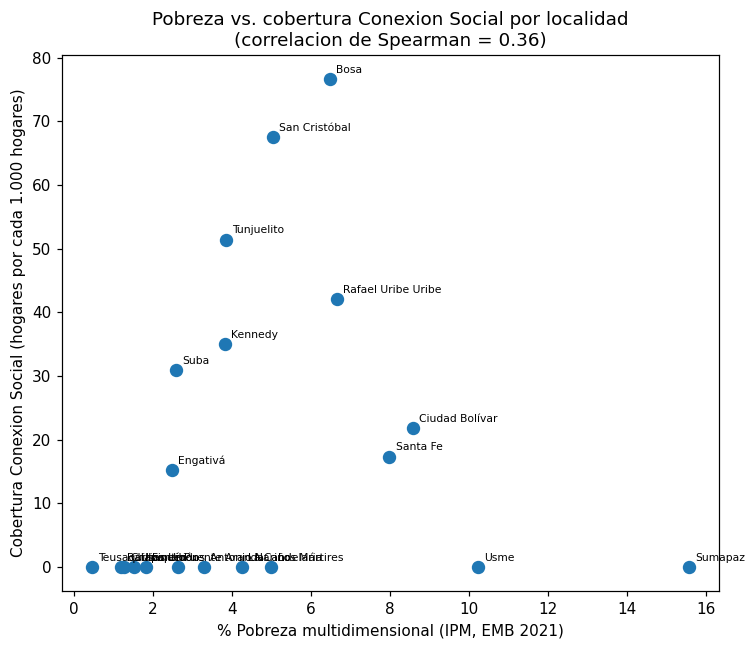

In [14]:
cruce_localidad.drop(columns="LOC_KEY").to_csv(
    OUT_TABLES / "cruce_localidad_pobreza_conexion_social.csv", index=False
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cruce_localidad["pct_pobreza_ipm"], cruce_localidad["cobertura_cs_por_1000_hogares"], s=60)
for _, row in cruce_localidad.iterrows():
    ax.annotate(row["NOMBRE_LOCALIDAD"], (row["pct_pobreza_ipm"], row["cobertura_cs_por_1000_hogares"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("% Pobreza multidimensional (IPM, EMB 2021)")
ax.set_ylabel("Cobertura Conexion Social (hogares por cada 1.000 hogares)")
ax.set_title(f"Pobreza vs. cobertura Conexion Social por localidad\n(correlacion de Spearman = {corr:.2f})")
fig.tight_layout()
fig.savefig(OUT_FIGS / "dispersion_pobreza_vs_cobertura_localidad.png", dpi=150)
plt.show()


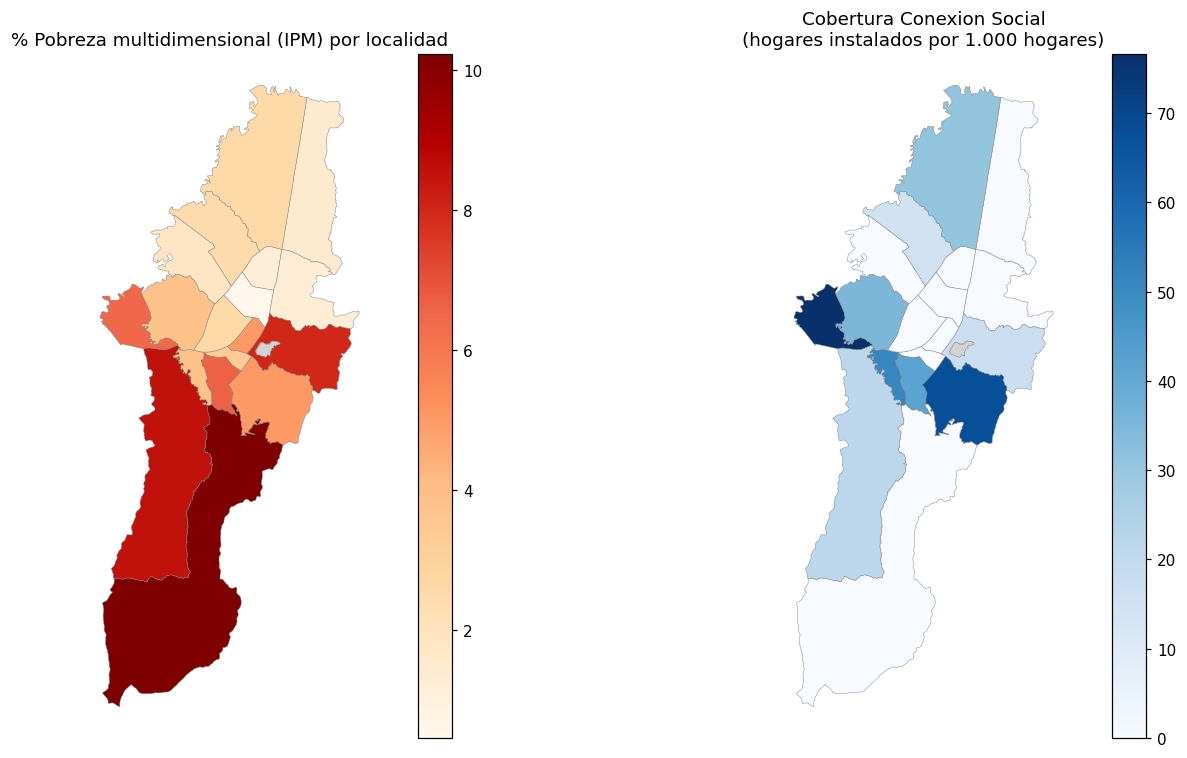

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

mapa_localidad = gdf_localidad_urbano.merge(cruce_localidad, on="LOC_KEY", how="left")

mapa_localidad.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=axes[0],
              edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[0].set_title("% Pobreza multidimensional (IPM) por localidad")
axes[0].axis("off")

mapa_localidad.plot(column="cobertura_cs_por_1000_hogares", cmap="Blues", legend=True, ax=axes[1],
              edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[1].set_title("Cobertura Conexion Social\n(hogares instalados por 1.000 hogares)")
axes[1].axis("off")

fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_pobreza_vs_cobertura_localidad.png", dpi=150)
plt.show()


Mismos datos, pero a nivel de **UPZ** (mas detalle que localidad), con el
**limite de cada localidad marcado en linea gruesa** encima para no perder esa
referencia. El color sigue siendo el mismo para todas las UPZ de un mismo grupo EMB
(seccion 4.1), asi que el detalle real es el de la EMB, no el de la UPZ individual.
Se conservan los dos mapas -- localidad arriba, UPZ aqui abajo -- porque cada uno
sirve para una lectura distinta.


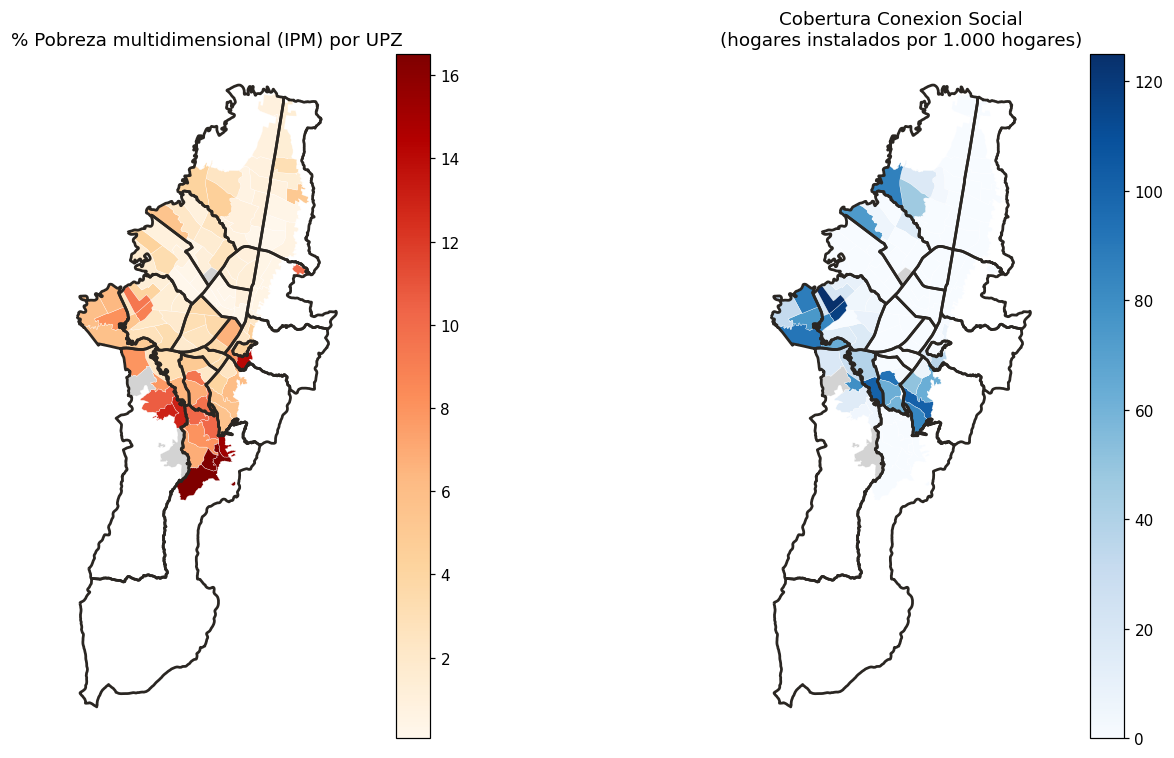

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

mapa_upz = gdf_upz_choropleth.merge(cruce_upz, on="NOMBRE_UPZ_GRUPO", how="left")

mapa_upz.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=axes[0],
              edgecolor="white", linewidth=0.2, missing_kwds={"color": "lightgrey"})
gdf_localidad_urbano.boundary.plot(ax=axes[0], color="#2A2622", linewidth=1.8)
axes[0].set_title("% Pobreza multidimensional (IPM) por UPZ")
axes[0].axis("off")

mapa_upz.plot(column="cobertura_cs_por_1000_hogares", cmap="Blues", legend=True, ax=axes[1],
              edgecolor="white", linewidth=0.2, missing_kwds={"color": "lightgrey"})
gdf_localidad_urbano.boundary.plot(ax=axes[1], color="#2A2622", linewidth=1.8)
axes[1].set_title("Cobertura Conexion Social\n(hogares instalados por 1.000 hogares)")
axes[1].axis("off")

fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_pobreza_vs_cobertura_upz.png", dpi=150)
plt.show()


### 6.1 Correlacion solo dentro de las localidades ya abiertas

La correlacion de arriba incluye localidades con cobertura 0 porque el programa
todavia no llega ahi -- eso no es un problema de focalizacion, es la fase del
despliegue. Aqui se repite el calculo **solo entre las localidades que ya tienen
instalaciones**, que es la pregunta que realmente importa: dentro de donde el
programa ya opera, ¿esta llegando mas a donde hay mas pobreza?


In [17]:
cruce_abiertas = cruce_localidad[cruce_localidad["LOC_KEY"].isin(LOCALIDADES_ABIERTAS)]
corr_abiertas = cruce_abiertas[["pct_pobreza_ipm", "cobertura_cs_por_1000_hogares"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion de Spearman (pobreza IPM vs. cobertura CS), solo localidades abiertas: {corr_abiertas:.2f}")
cruce_abiertas.sort_values("pct_pobreza_ipm", ascending=False)


Correlacion de Spearman (pobreza IPM vs. cobertura CS), solo localidades abiertas: 0.10


,NOMBRE_LOCALIDAD,pct_pobreza_ipm,hogares_totales_estimados_emb,LOC_KEY,hogares_cs,cobertura_cs_por_1000_hogares
2,Ciudad Bolívar,8.576726,208702.085748,CIUDAD BOLIVAR,4551.0,21.806203
3,Santa Fe,7.991648,39064.354319,SANTA FE,677.0,17.330377
4,Rafael Uribe Uribe,6.667842,136687.354445,RAFAEL URIBE URIBE,5760.0,42.139963
5,Bosa,6.489109,233692.505621,BOSA,17905.0,76.617776
6,San Cristóbal,5.036779,135671.094960,SAN CRISTOBAL,9170.0,67.589931
9,Tunjuelito,3.845420,70431.856300,TUNJUELITO,3623.0,51.439791
10,Kennedy,3.824175,365083.846326,KENNEDY,12790.0,35.033048
13,Suba,2.596204,446351.779625,SUBA,13790.0,30.894914
14,Engativá,2.473208,297273.402638,ENGATIVA,4531.0,15.241861


### 6.2 Cruce a nivel de UPZ (grupo EMB)

`cruce_upz` ya se calculo en la seccion 4.1 (se necesitaba temprano para los mapas por
UPZ); aqui solo se exporta y se muestra.


In [18]:
cruce_upz.to_csv(OUT_TABLES / "cruce_upz_pobreza_conexion_social.csv", index=False)

corr_upz = cruce_upz[["pct_pobreza_ipm", "cobertura_cs_por_1000_hogares"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion de Spearman (pobreza IPM vs. cobertura CS) por grupo de UPZ: {corr_upz:.2f}")
cruce_upz.head(15)


Correlacion de Spearman (pobreza IPM vs. cobertura CS) por grupo de UPZ: 0.57


,NOMBRE_UPZ_GRUPO,pct_pobreza_ipm,hogares_totales_estimados_emb,hogares_cs,cobertura_cs_por_1000_hogares
88,USME: Alfonso López + Ciudad Usme,16.510320,25148.782425,2.0,0.079527
42,La Flora,15.266510,6762.234654,2.0,0.295760
54,Lourdes,14.072589,13755.443256,496.0,36.058453
12,CIUDAD BOLÍVAR: Monteblanco + El Tesoro + El M...,13.000301,18859.672774,90.0,4.772087
55,Lucero,10.618561,54244.144513,841.0,15.503978
89,USME: Parque Entrenubes + Danubio,10.161630,18905.434955,2.0,0.105790
72,San Isidro - Patios,10.089829,5746.487615,0.0,0.000000
22,Diana Turbay,9.707758,26469.746768,1575.0,59.501891
56,Marco Fidel Suárez,9.461298,18328.179787,1701.0,92.807907
63,Patio Bonito,9.438808,45151.630743,5643.0,124.978875


### 6.3 Mapa combinado: intensidad de IPM + ubicacion de los hogares CS

Un unico mapa con la intensidad de pobreza multidimensional (relleno de color por
localidad) y, encima, un punto por cada hogar instalado de Conexion Social.

> **Nota de privacidad:** a diferencia de las demas figuras de este notebook, este
> mapa grafica la **coordenada exacta de cada hogar verificado** (Localidad declarada = geometrica). Se genera y
> se sube por decision explicita del equipo. Si en algun momento este mapa va a
> circular fuera del equipo (jurados externos, publicaciones, etc.), es preferible
> usar una version de densidad (hexbin/mapa de calor) en vez de puntos exactos, para
> no exponer la ubicacion precisa de hogares vulnerables.


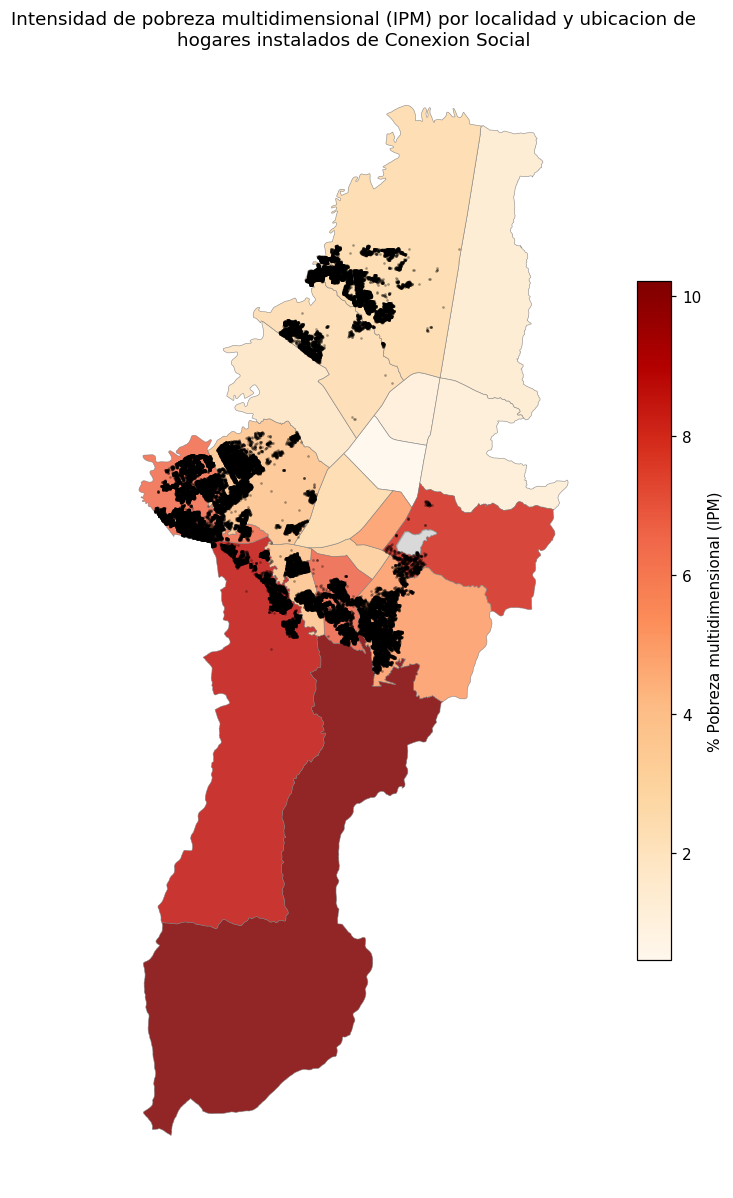

In [19]:
fig, ax = plt.subplots(figsize=(9, 11))

mapa_localidad.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=ax,
                     edgecolor="grey", linewidth=0.4, alpha=0.85,
                     missing_kwds={"color": "lightgrey"},
                     legend_kwds={"label": "% Pobreza multidimensional (IPM)", "shrink": 0.6})

gdf_cs_verificados.plot(ax=ax, markersize=3, color="black", alpha=0.35, linewidth=0)

ax.set_title("Intensidad de pobreza multidimensional (IPM) por localidad y ubicacion de\nhogares instalados de Conexion Social")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_ipm_con_hogares_cs.png", dpi=150)
plt.show()


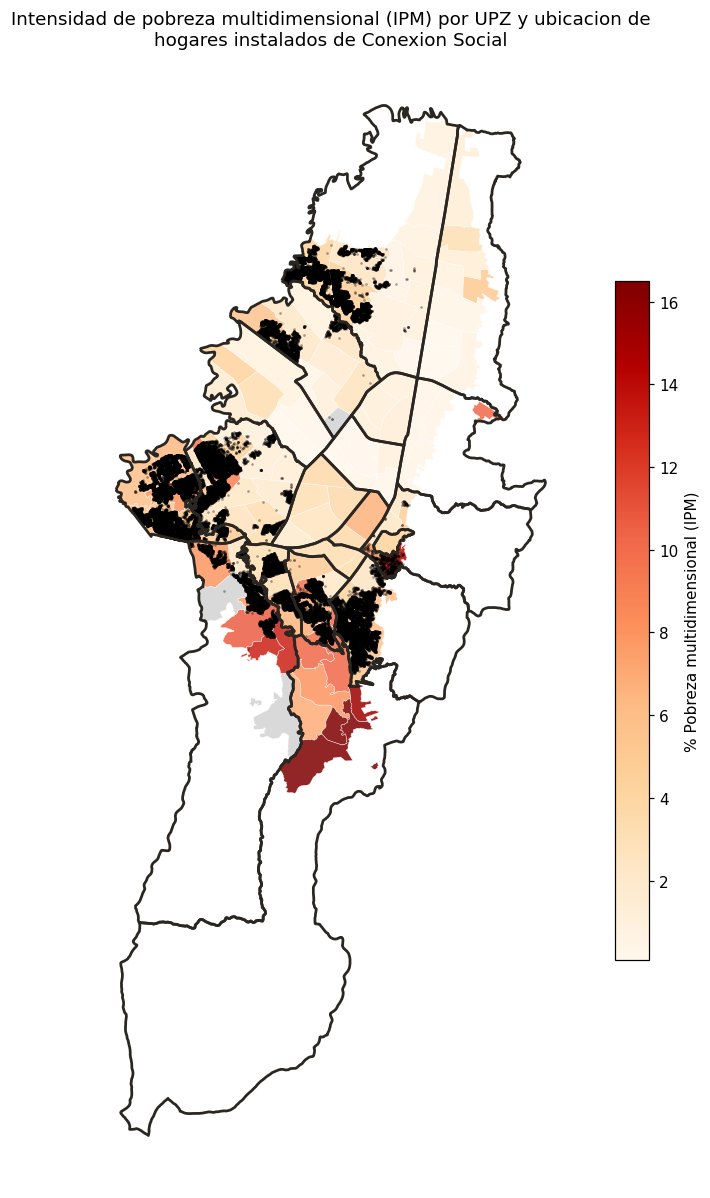

In [20]:
fig, ax = plt.subplots(figsize=(9, 11))

mapa_upz.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=ax,
              edgecolor="white", linewidth=0.3, alpha=0.85,
              missing_kwds={"color": "lightgrey"},
              legend_kwds={"label": "% Pobreza multidimensional (IPM)", "shrink": 0.6})
gdf_localidad_urbano.boundary.plot(ax=ax, color="#2A2622", linewidth=1.8)

gdf_cs_verificados.plot(ax=ax, markersize=3, color="black", alpha=0.35, linewidth=0)

ax.set_title("Intensidad de pobreza multidimensional (IPM) por UPZ y ubicacion de\nhogares instalados de Conexion Social")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_ipm_con_hogares_cs_upz.png", dpi=150)
plt.show()


## 7. Distribucion por sector catastral (solo descriptiva)

**Limitacion estadistica:** la EMB 2021 esta diseñada para ser representativa a nivel
de localidad y, con mayor margen de error, a nivel de grupo de UPZ. **No tiene tamaño
de muestra suficiente para estimar el IPM de forma confiable a nivel de sector
catastral** (unidades mucho mas pequeñas que una UPZ). Por eso esta seccion solo
muestra donde se concentran las instalaciones de Conexion Social a ese nivel de
detalle, sin cruzarlo contra pobreza. Esto confirma el hallazgo de la nota tecnica del
equipo: los datos publicos disponibles no permiten un analisis de focalizacion
intra-local con la misma fuente de pobreza.


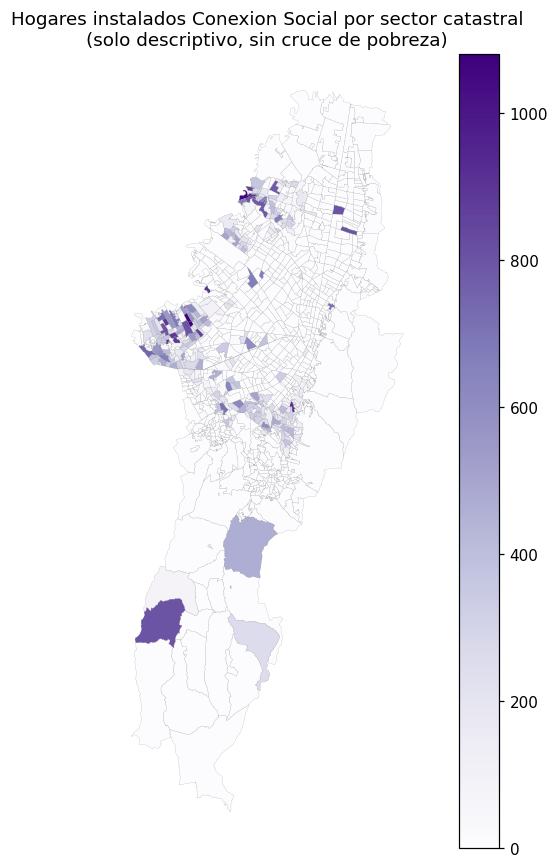

In [21]:
cs_sector_geo = gdf_sector.merge(cs_sector, left_on="SCANOMBRE", right_on="SCaNombre", how="left")
cs_sector_geo["hogares_cs"] = cs_sector_geo["hogares_cs"].fillna(0)
cs_sector_geo.to_file(GEO_DIR / "sector_catastral_hogares_cs.geojson", driver="GeoJSON")

cs_sector.sort_values("hogares_cs", ascending=False).to_csv(
    OUT_TABLES / "hogares_cs_por_sector_catastral.csv", index=False
)

# Para el mapa se recorta a la extension urbana (ver nota cartografica de la seccion 2)
cs_sector_geo_urbano = cs_sector_geo[cs_sector_geo.intersects(area_urbana_union)]

fig, ax = plt.subplots(figsize=(8, 8))
cs_sector_geo_urbano.plot(column="hogares_cs", cmap="Purples", legend=True, ax=ax,
                    edgecolor="grey", linewidth=0.1)
ax.set_title("Hogares instalados Conexion Social por sector catastral\n(solo descriptivo, sin cruce de pobreza)")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_hogares_cs_sector_catastral.png", dpi=150)
plt.show()


## 8. Matricula oficial SIMAT (numero de estudiantes por colegio)

Se incorpora `Simat_1Jul26.csv` (corte 31/05/2026, ~670.000 registros de matricula
"DISTRITAL"). Es un microdato con datos personales de cada estudiante (nombre,
documento de identidad, direccion de residencia, telefono, correo, fecha de
nacimiento, discapacidad, etnia, etc.).

> **Regla de privacidad de esta seccion:** el notebook **nunca lee** esas columnas
> personales -- solo se seleccionan (`usecols`) las columnas geograficas y de
> establecimiento educativo necesarias para contar estudiantes por localidad, UPZ y
> colegio. Ni una fila individual de estudiante se muestra, exporta ni sube a GitHub;
> solo conteos agregados. El archivo original tampoco se sube (ver `.gitignore`).


In [22]:
COLS_SIMAT = [
    "num_localidad", "nom_localidad", "num_upz", "nom_upz",
    "dane12_ee", "nom_establecimiento_educativo", "clase",
]

cache_simat = PROCESSED_DIR / "simat_agregado.parquet"
if cache_simat.exists():
    df_simat = pd.read_parquet(cache_simat)
else:
    df_simat = pd.read_csv(
        DATA_DIR / "Simat_1Jul26.csv", sep=";", encoding="latin1",
        usecols=COLS_SIMAT, engine="pyarrow",
    )
    df_simat = df_simat[df_simat["clase"].str.startswith("DISTRITAL")].copy()
    # Armonizacion manual de nombre de localidad: SED usa "SANTAFE" (una palabra)
    # mientras que SDP/IDECA usan "SANTA FE" (dos palabras) para la misma localidad.
    # Es exactamente el tipo de diferencia de nomenclatura entre entidades que
    # documenta la nota tecnica del equipo.
    df_simat["nom_localidad"] = df_simat["nom_localidad"].replace({"SANTAFE": "SANTA FE"})
    df_simat.to_parquet(cache_simat)

df_simat["LOC_KEY"] = df_simat["nom_localidad"].apply(normalizar)
df_simat["upz_key"] = df_simat["nom_upz"].apply(normalizar)
df_simat["NOMBRE_UPZ_GRUPO"] = df_simat["upz_key"].map(crosswalk)

print("Estudiantes matriculados en colegios oficiales (SIMAT, corte 31/05/2026):", len(df_simat))
print("Establecimientos educativos oficiales unicos:", df_simat["dane12_ee"].nunique())
print(f"Registros SIMAT con UPZ emparejada a un grupo EMB: {df_simat['NOMBRE_UPZ_GRUPO'].notna().mean() * 100:.1f}%")


Estudiantes matriculados en colegios oficiales (SIMAT, corte 31/05/2026): 669663
Establecimientos educativos oficiales unicos: 412
Registros SIMAT con UPZ emparejada a un grupo EMB: 98.9%


### 8.1 Estudiantes por establecimiento educativo, localidad y UPZ

In [23]:
estudiantes_colegio = (
    df_simat.groupby(["dane12_ee", "nom_establecimiento_educativo", "nom_localidad"])
    .size().rename("estudiantes_oficiales").reset_index()
    .sort_values("estudiantes_oficiales", ascending=False)
)
estudiantes_colegio.to_csv(OUT_TABLES / "estudiantes_simat_por_establecimiento.csv", index=False)

estudiantes_localidad = (
    df_simat.groupby(["nom_localidad", "LOC_KEY"]).size()
    .rename("estudiantes_oficiales").reset_index()
)
estudiantes_upz_grupo = (
    df_simat.groupby("NOMBRE_UPZ_GRUPO").size()
    .rename("estudiantes_oficiales").reset_index()
)

print(f"{len(estudiantes_colegio)} colegios oficiales con estudiantes matriculados")
estudiantes_colegio.head(10)


412 colegios oficiales con estudiantes matriculados


,dane12_ee,nom_establecimiento_educativo,nom_localidad,estudiantes_oficiales
308,111001107875,COLEGIO CIUDADELA EDUCATIVA DE BOSA (IED),BOSA,5861
132,111001024732,COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED),KENNEDY,5273
144,111001027391,COLEGIO MANUEL CEPEDA VARGAS (IED),KENNEDY,5061
370,111769003424,COLEGIO GERARDO PAREDES (IED),SUBA,4937
368,111769003360,COLEGIO REPUBLICA DOMINICANA (IED),SUBA,4692
239,111001086801,COLEGIO CEDID CIUDAD BOLIVAR (IED),CIUDAD BOLIVAR,4673
9,111001002909,COLEGIO CARLOS ALBAN HOLGUIN (IED),BOSA,4510
240,111001086835,COLEGIO SIERRA MORENA (IED),CIUDAD BOLIVAR,4447
348,111102000753,COLEGIO FERNANDO MAZUERA VILLEGAS (IED),BOSA,4346
387,211102000243,COLEGIO EL PORVENIR (IED),BOSA,3995


### 8.2 Cruce SIMAT vs. pobreza (IPM) y vs. Conexion Social, por localidad

Se arma una tabla unica a nivel de localidad (`comparacion_localidad`) con las tres
fuentes: **% pobreza multidimensional** (EMB), **cobertura de Conexion Social** y
**estudiantes matriculados en colegios oficiales** (SIMAT). Se agrega tambien
`cobertura_cs_por_1000_estudiantes`: cuantos hogares conectados hay por cada 1.000
estudiantes de colegio oficial en la localidad -- una medida de que tan alineado esta
el programa con la necesidad educativa, análoga a la cobertura ya calculada frente a
pobreza en la seccion 6.


In [24]:
comparacion_localidad = cruce_localidad.merge(
    estudiantes_localidad[["LOC_KEY", "estudiantes_oficiales"]], on="LOC_KEY", how="left"
)
comparacion_localidad["estudiantes_oficiales"] = comparacion_localidad["estudiantes_oficiales"].fillna(0)
comparacion_localidad["cobertura_cs_por_1000_estudiantes"] = (
    comparacion_localidad["hogares_cs"] / comparacion_localidad["estudiantes_oficiales"] * 1000
).replace([np.inf, -np.inf], np.nan)

comparacion_localidad.drop(columns="LOC_KEY").to_csv(
    OUT_TABLES / "comparacion_ipm_cs_simat_localidad.csv", index=False
)

corr_ipm_simat = comparacion_localidad[["pct_pobreza_ipm", "estudiantes_oficiales"]].corr(method="spearman").iloc[0, 1]
corr_cs_simat = comparacion_localidad[["hogares_cs", "estudiantes_oficiales"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion de Spearman (pobreza IPM vs. estudiantes oficiales) por localidad: {corr_ipm_simat:.2f}")
print(f"Correlacion de Spearman (hogares CS vs. estudiantes oficiales) por localidad: {corr_cs_simat:.2f}")
comparacion_localidad.sort_values("estudiantes_oficiales", ascending=False)


Correlacion de Spearman (pobreza IPM vs. estudiantes oficiales) por localidad: 0.21
Correlacion de Spearman (hogares CS vs. estudiantes oficiales) por localidad: 0.77


,NOMBRE_LOCALIDAD,pct_pobreza_ipm,hogares_totales_estimados_emb,LOC_KEY,hogares_cs,cobertura_cs_por_1000_hogares,estudiantes_oficiales,cobertura_cs_por_1000_estudiantes
5,Bosa,6.489109,233692.505621,BOSA,17905.0,76.617776,98415.0,181.933648
10,Kennedy,3.824175,365083.846326,KENNEDY,12790.0,35.033048,91488.0,139.799755
2,Ciudad Bolívar,8.576726,208702.085748,CIUDAD BOLIVAR,4551.0,21.806203,89415.0,50.897500
13,Suba,2.596204,446351.779625,SUBA,13790.0,30.894914,69503.0,198.408702
1,Usme,10.226706,128688.921145,USME,0.0,0.000000,59064.0,0.000000
14,Engativá,2.473208,297273.402638,ENGATIVA,4531.0,15.241861,52622.0,86.104671
4,Rafael Uribe Uribe,6.667842,136687.354445,RAFAEL URIBE URIBE,5760.0,42.139963,43129.0,133.552830
6,San Cristóbal,5.036779,135671.094960,SAN CRISTOBAL,9170.0,67.589931,40391.0,227.030774
9,Tunjuelito,3.845420,70431.856300,TUNJUELITO,3623.0,51.439791,25857.0,140.116796
15,Fontibón,1.832845,146776.900628,FONTIBON,0.0,0.000000,22992.0,0.000000


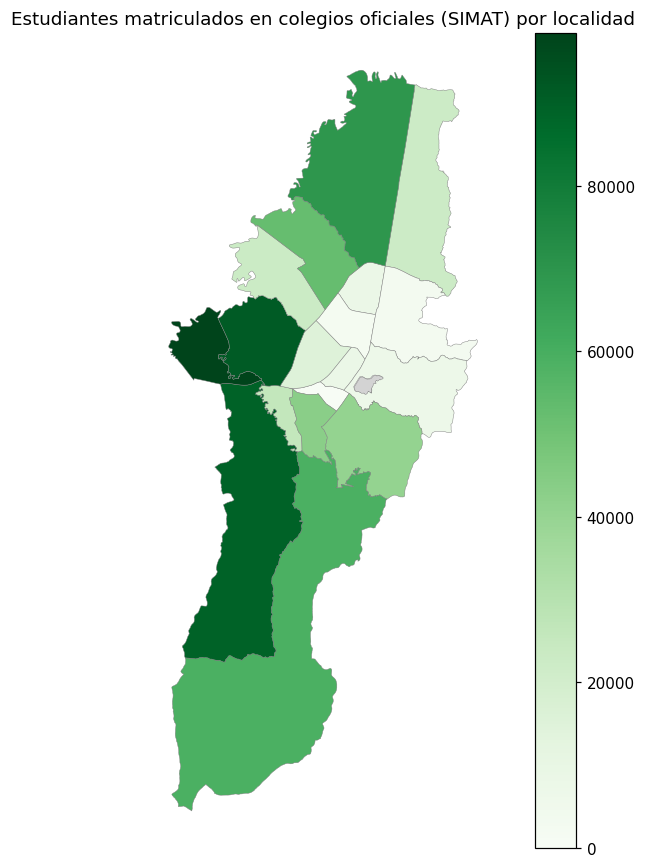

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
mapa_simat_localidad = gdf_localidad_urbano.merge(comparacion_localidad, on="LOC_KEY", how="left")
mapa_simat_localidad.plot(column="estudiantes_oficiales", cmap="Greens", legend=True, ax=ax,
                           edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
ax.set_title("Estudiantes matriculados en colegios oficiales (SIMAT) por localidad")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_estudiantes_simat_localidad.png", dpi=150)
plt.show()


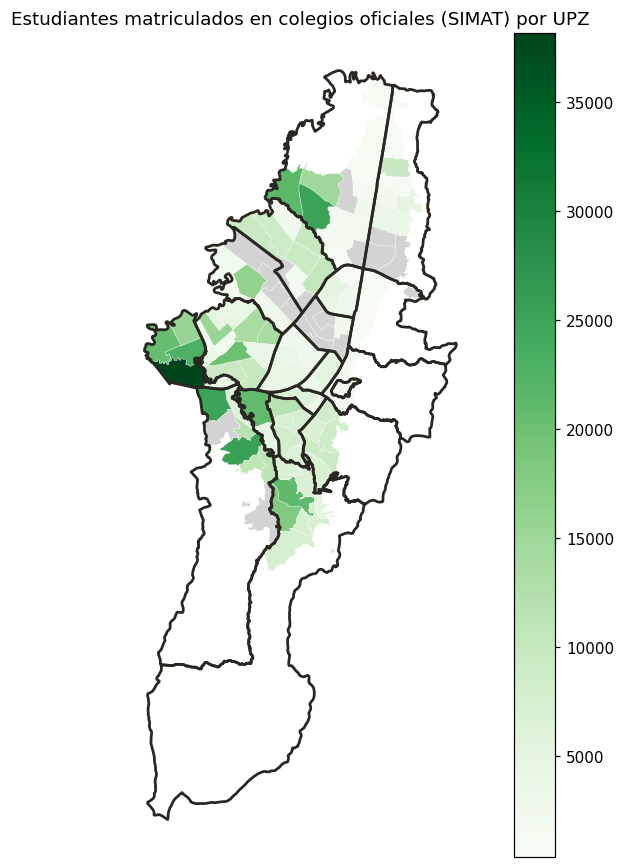

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
mapa_upz_simat = gdf_upz_choropleth.merge(estudiantes_upz_grupo, on="NOMBRE_UPZ_GRUPO", how="left")
mapa_upz_simat.plot(column="estudiantes_oficiales", cmap="Greens", legend=True, ax=ax,
                     edgecolor="white", linewidth=0.2, missing_kwds={"color": "lightgrey"})
gdf_localidad_urbano.boundary.plot(ax=ax, color="#2A2622", linewidth=1.8)
ax.set_title("Estudiantes matriculados en colegios oficiales (SIMAT) por UPZ")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_estudiantes_simat_upz.png", dpi=150)
plt.show()


### 8.3 Mapa combinado: intensidad de matricula SIMAT + ubicacion de los hogares CS

Mismo formato que el mapa de la seccion 6.3, pero con la intensidad de matricula
oficial (SIMAT) como capa de fondo en vez del IPM. Se conservan las dos versiones
(localidad y UPZ), igual que en la seccion 6.

> **Nota de privacidad:** al igual que en la seccion 6.3, este mapa grafica la
> coordenada exacta de cada hogar verificado (Localidad declarada = geometrica). Se genera y se sube
> por la misma decision explicita del equipo.


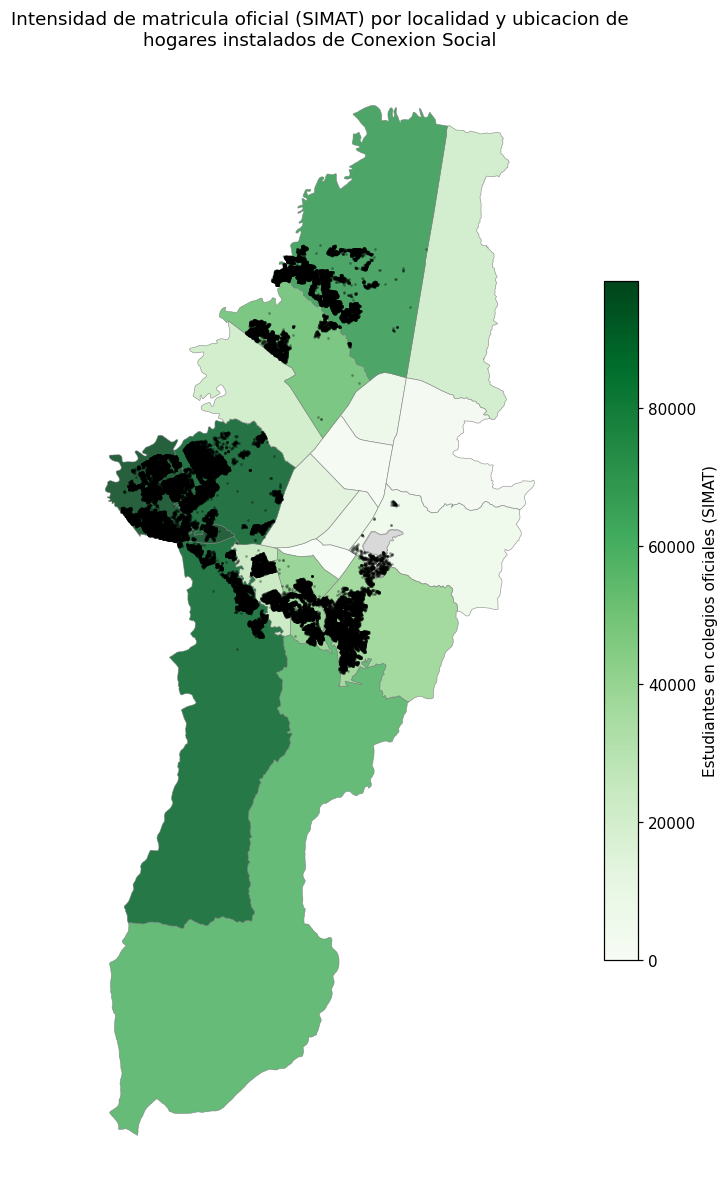

In [27]:
fig, ax = plt.subplots(figsize=(9, 11))

mapa_simat_localidad.plot(column="estudiantes_oficiales", cmap="Greens", legend=True, ax=ax,
                           edgecolor="grey", linewidth=0.4, alpha=0.85,
                           missing_kwds={"color": "lightgrey"},
                           legend_kwds={"label": "Estudiantes en colegios oficiales (SIMAT)", "shrink": 0.6})

gdf_cs_verificados.plot(ax=ax, markersize=3, color="black", alpha=0.35, linewidth=0)

ax.set_title("Intensidad de matricula oficial (SIMAT) por localidad y ubicacion de\nhogares instalados de Conexion Social")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_simat_con_hogares_cs.png", dpi=150)
plt.show()


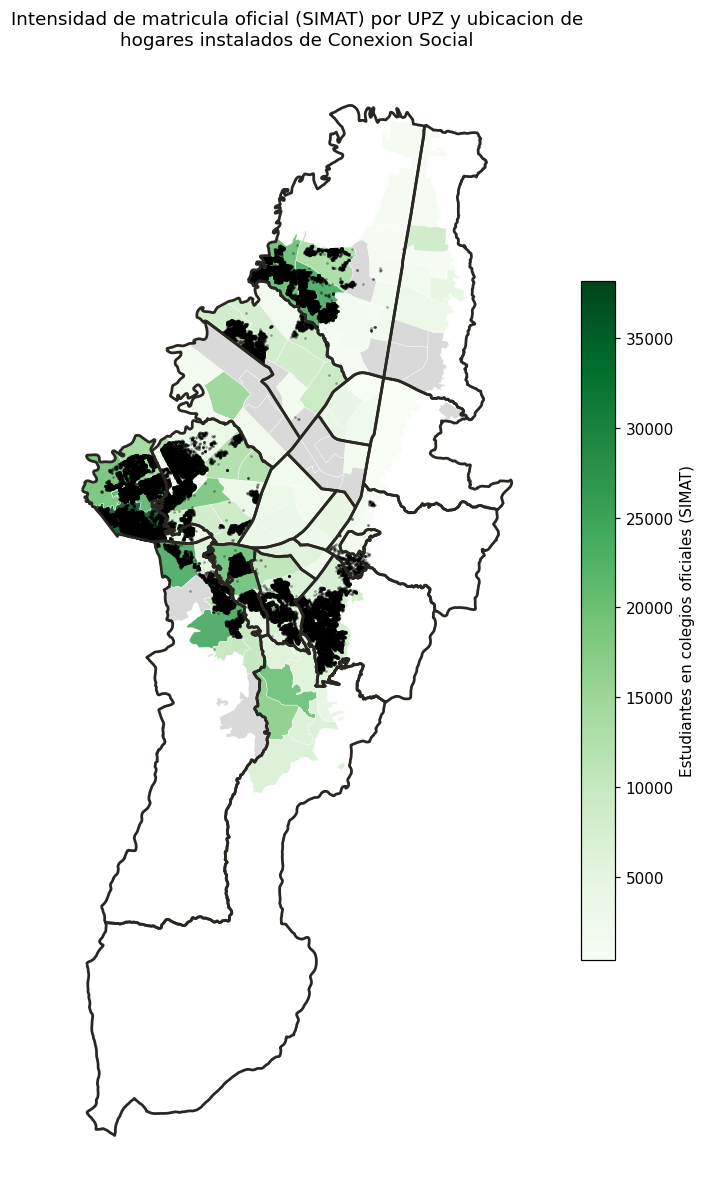

In [28]:
fig, ax = plt.subplots(figsize=(9, 11))

mapa_upz_simat.plot(column="estudiantes_oficiales", cmap="Greens", legend=True, ax=ax,
                     edgecolor="white", linewidth=0.3, alpha=0.85,
                     missing_kwds={"color": "lightgrey"},
                     legend_kwds={"label": "Estudiantes en colegios oficiales (SIMAT)", "shrink": 0.6})
gdf_localidad_urbano.boundary.plot(ax=ax, color="#2A2622", linewidth=1.8)

gdf_cs_verificados.plot(ax=ax, markersize=3, color="black", alpha=0.35, linewidth=0)

ax.set_title("Intensidad de matricula oficial (SIMAT) por UPZ y ubicacion de\nhogares instalados de Conexion Social")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_simat_con_hogares_cs_upz.png", dpi=150)
plt.show()


### 8.4 A nivel de UPZ (grupo EMB)

In [29]:
comparacion_upz = ipm_upz.merge(cs_por_grupo_upz, on="NOMBRE_UPZ_GRUPO", how="left")
comparacion_upz = comparacion_upz.merge(estudiantes_upz_grupo, on="NOMBRE_UPZ_GRUPO", how="left")
comparacion_upz[["hogares_cs", "estudiantes_oficiales"]] = comparacion_upz[["hogares_cs", "estudiantes_oficiales"]].fillna(0)
comparacion_upz["cobertura_cs_por_1000_hogares"] = (
    comparacion_upz["hogares_cs"] / comparacion_upz["hogares_totales_estimados_emb"] * 1000
)
comparacion_upz["cobertura_cs_por_1000_estudiantes"] = (
    comparacion_upz["hogares_cs"] / comparacion_upz["estudiantes_oficiales"] * 1000
).replace([np.inf, -np.inf], np.nan)
comparacion_upz = comparacion_upz.sort_values("pct_pobreza_ipm", ascending=False)
comparacion_upz.to_csv(OUT_TABLES / "comparacion_ipm_cs_simat_upz.csv", index=False)
comparacion_upz.head(15)


,NOMBRE_UPZ_GRUPO,pct_pobreza_ipm,hogares_totales_estimados_emb,hogares_cs,estudiantes_oficiales,cobertura_cs_por_1000_hogares,cobertura_cs_por_1000_estudiantes
88,USME: Alfonso López + Ciudad Usme,16.510320,25148.782425,2.0,7499.0,0.079527,0.266702
42,La Flora,15.266510,6762.234654,2.0,4885.0,0.295760,0.409417
54,Lourdes,14.072589,13755.443256,496.0,2448.0,36.058453,202.614379
12,CIUDAD BOLÍVAR: Monteblanco + El Tesoro + El M...,13.000301,18859.672774,90.0,11070.0,4.772087,8.130081
55,Lucero,10.618561,54244.144513,841.0,25340.0,15.503978,33.188635
89,USME: Parque Entrenubes + Danubio,10.161630,18905.434955,2.0,6730.0,0.105790,0.297177
72,San Isidro - Patios,10.089829,5746.487615,0.0,0.0,0.000000,NaN
22,Diana Turbay,9.707758,26469.746768,1575.0,6617.0,59.501891,238.023273
56,Marco Fidel Suárez,9.461298,18328.179787,1701.0,6946.0,92.807907,244.889145
63,Patio Bonito,9.438808,45151.630743,5643.0,15362.0,124.978875,367.334982


## 9. Comparacion conjunta: pobreza (IPM), Conexion Social y SIMAT

Con `comparacion_localidad` ya listas las tres fuentes, se comparan directamente:

- **% pobreza multidimensional** (IPM, EMB 2021) - la necesidad.
- **Cobertura de Conexion Social** (hogares por 1.000 hogares, seccion 6) - la oferta
  del programa frente al universo de hogares.
- **Cobertura de Conexion Social frente a matricula oficial** (hogares CS por 1.000
  estudiantes, seccion 8.2) - la oferta del programa frente a la poblacion escolar
  publica, que es la poblacion objetivo mencionada en el formulario del equipo.

Una correlacion positiva y fuerte entre pobreza y ambas coberturas indicaria buena
focalizacion; correlaciones bajas o negativas (como las que se observan aqui)
respaldan la hipotesis de desajuste territorial planteada por el equipo.


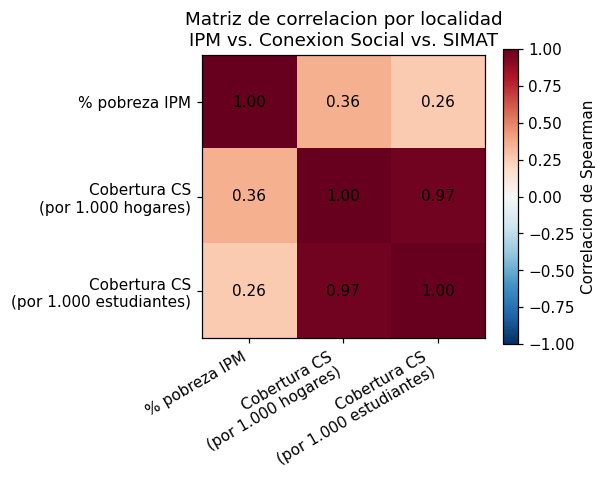

,% pobreza IPM,Cobertura CS\n(por 1.000 hogares),Cobertura CS\n(por 1.000 estudiantes)
% pobreza IPM,1.000000,0.357193,0.264636
Cobertura CS\n(por 1.000 hogares),0.357193,1.000000,0.967179
Cobertura CS\n(por 1.000 estudiantes),0.264636,0.967179,1.000000


In [30]:
vars_comparacion = ["pct_pobreza_ipm", "cobertura_cs_por_1000_hogares", "cobertura_cs_por_1000_estudiantes"]
matriz_corr = comparacion_localidad[vars_comparacion].corr(method="spearman")
matriz_corr.index = matriz_corr.columns = ["% pobreza IPM", "Cobertura CS\n(por 1.000 hogares)", "Cobertura CS\n(por 1.000 estudiantes)"]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(matriz_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(matriz_corr.columns, rotation=30, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels(matriz_corr.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{matriz_corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, label="Correlacion de Spearman")
ax.set_title("Matriz de correlacion por localidad\nIPM vs. Conexion Social vs. SIMAT")
fig.tight_layout()
fig.savefig(OUT_FIGS / "matriz_correlacion_ipm_cs_simat.png", dpi=150)
plt.show()
matriz_corr


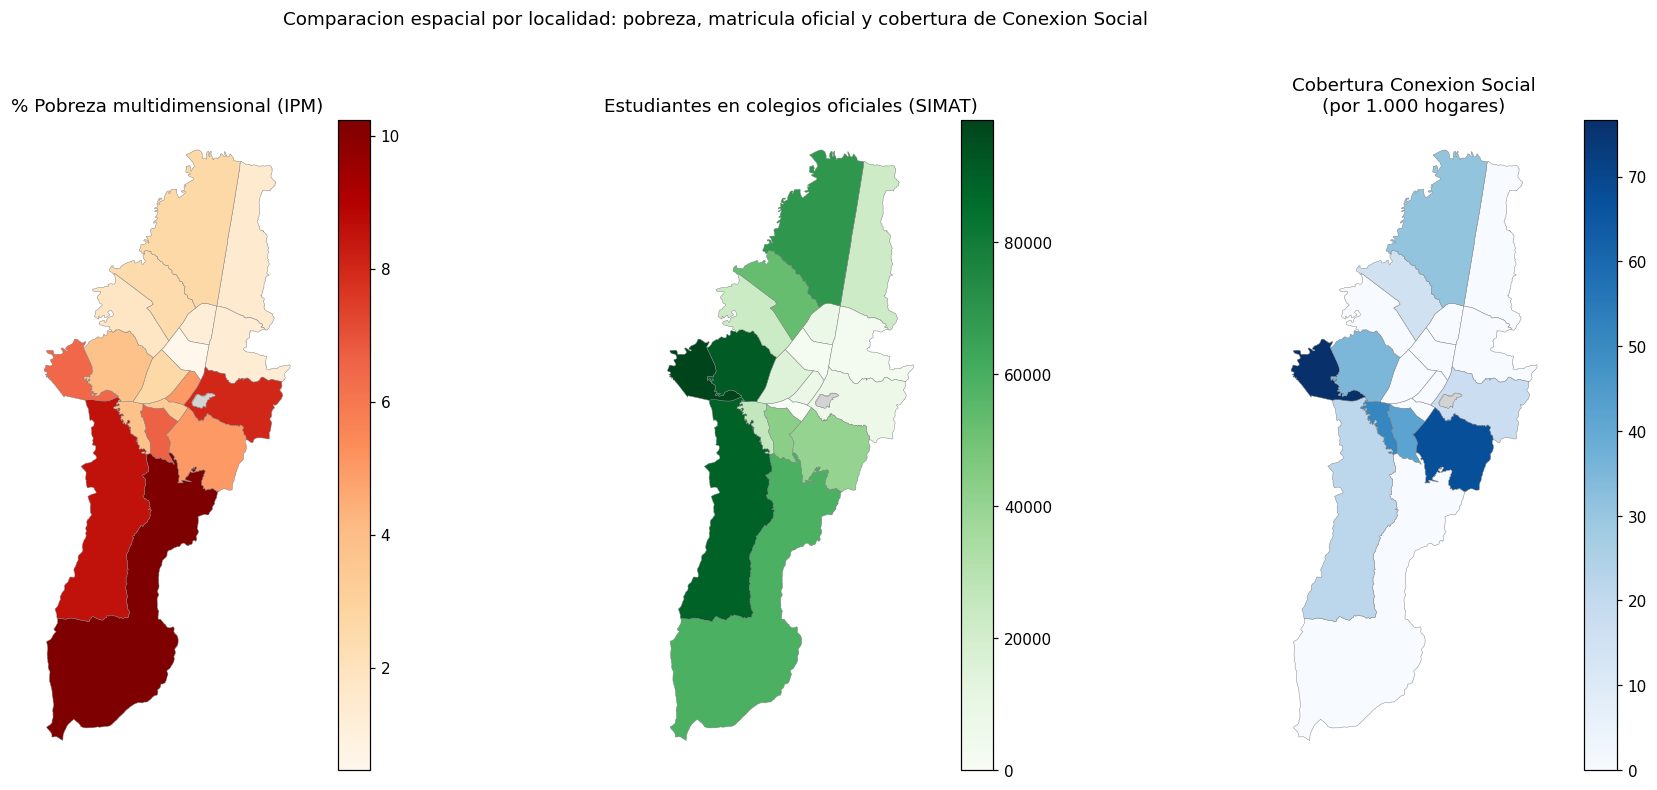

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

mapa_comp_localidad = gdf_localidad_urbano.merge(comparacion_localidad, on="LOC_KEY", how="left")

mapa_comp_localidad.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=axes[0],
               edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[0].set_title("% Pobreza multidimensional (IPM)")
axes[0].axis("off")

mapa_comp_localidad.plot(column="estudiantes_oficiales", cmap="Greens", legend=True, ax=axes[1],
               edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[1].set_title("Estudiantes en colegios oficiales (SIMAT)")
axes[1].axis("off")

mapa_comp_localidad.plot(column="cobertura_cs_por_1000_hogares", cmap="Blues", legend=True, ax=axes[2],
               edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[2].set_title("Cobertura Conexion Social\n(por 1.000 hogares)")
axes[2].axis("off")

fig.suptitle("Comparacion espacial por localidad: pobreza, matricula oficial y cobertura de Conexion Social", y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapas_comparacion_ipm_cs_simat.png", dpi=150, bbox_inches="tight")
plt.show()


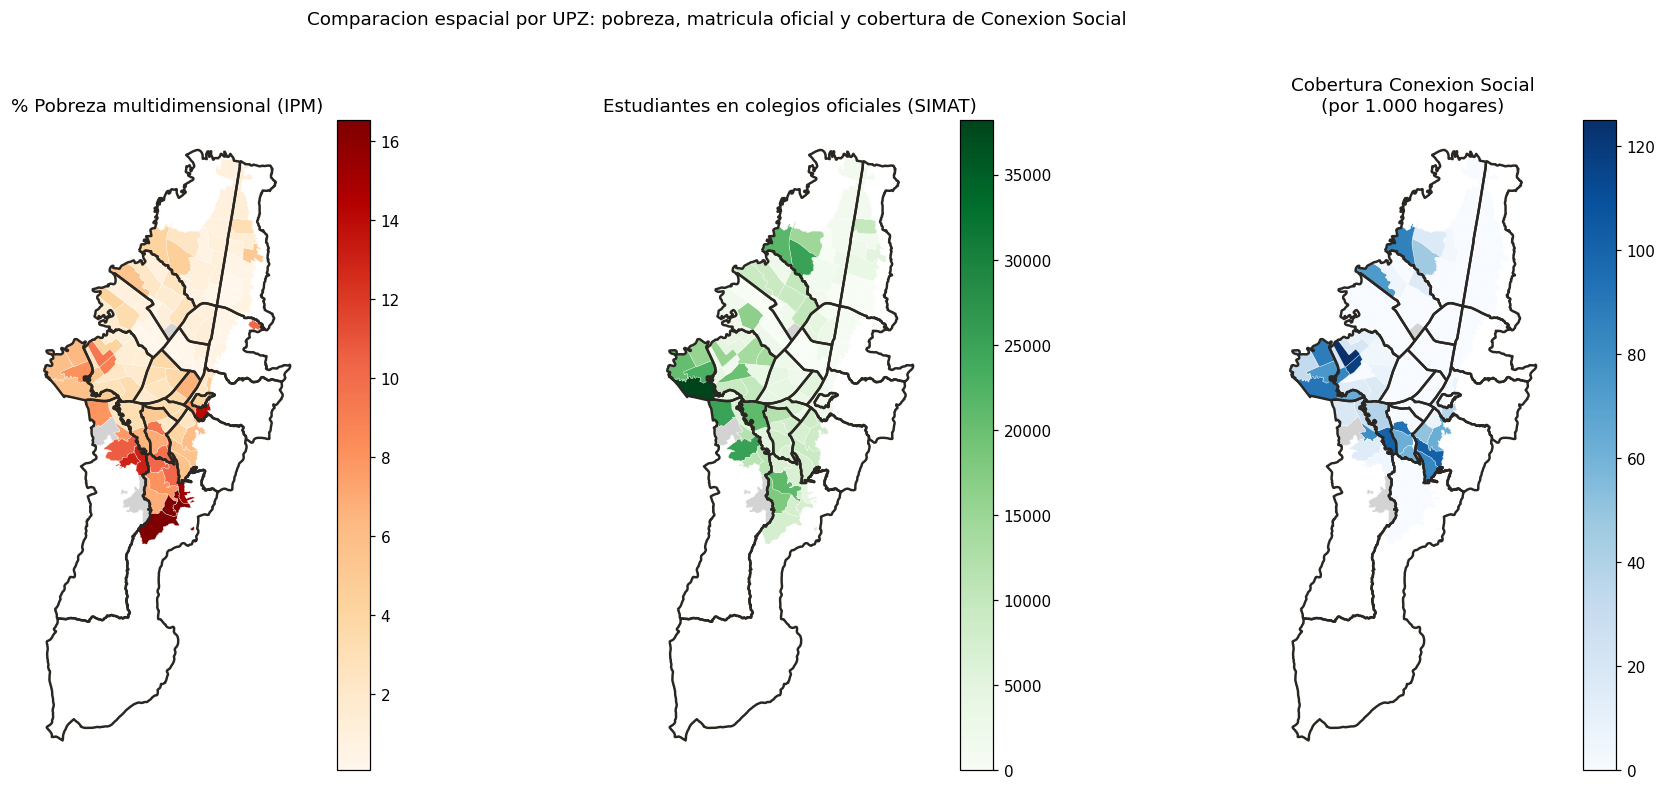

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

mapa_comp_upz = gdf_upz_choropleth.merge(comparacion_upz, on="NOMBRE_UPZ_GRUPO", how="left")

mapa_comp_upz.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=axes[0],
               edgecolor="white", linewidth=0.2, missing_kwds={"color": "lightgrey"})
gdf_localidad_urbano.boundary.plot(ax=axes[0], color="#2A2622", linewidth=1.6)
axes[0].set_title("% Pobreza multidimensional (IPM)")
axes[0].axis("off")

mapa_comp_upz.plot(column="estudiantes_oficiales", cmap="Greens", legend=True, ax=axes[1],
               edgecolor="white", linewidth=0.2, missing_kwds={"color": "lightgrey"})
gdf_localidad_urbano.boundary.plot(ax=axes[1], color="#2A2622", linewidth=1.6)
axes[1].set_title("Estudiantes en colegios oficiales (SIMAT)")
axes[1].axis("off")

mapa_comp_upz.plot(column="cobertura_cs_por_1000_hogares", cmap="Blues", legend=True, ax=axes[2],
               edgecolor="white", linewidth=0.2, missing_kwds={"color": "lightgrey"})
gdf_localidad_urbano.boundary.plot(ax=axes[2], color="#2A2622", linewidth=1.6)
axes[2].set_title("Cobertura Conexion Social\n(por 1.000 hogares)")
axes[2].axis("off")

fig.suptitle("Comparacion espacial por UPZ: pobreza, matricula oficial y cobertura de Conexion Social", y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapas_comparacion_ipm_cs_simat_upz.png", dpi=150, bbox_inches="tight")
plt.show()


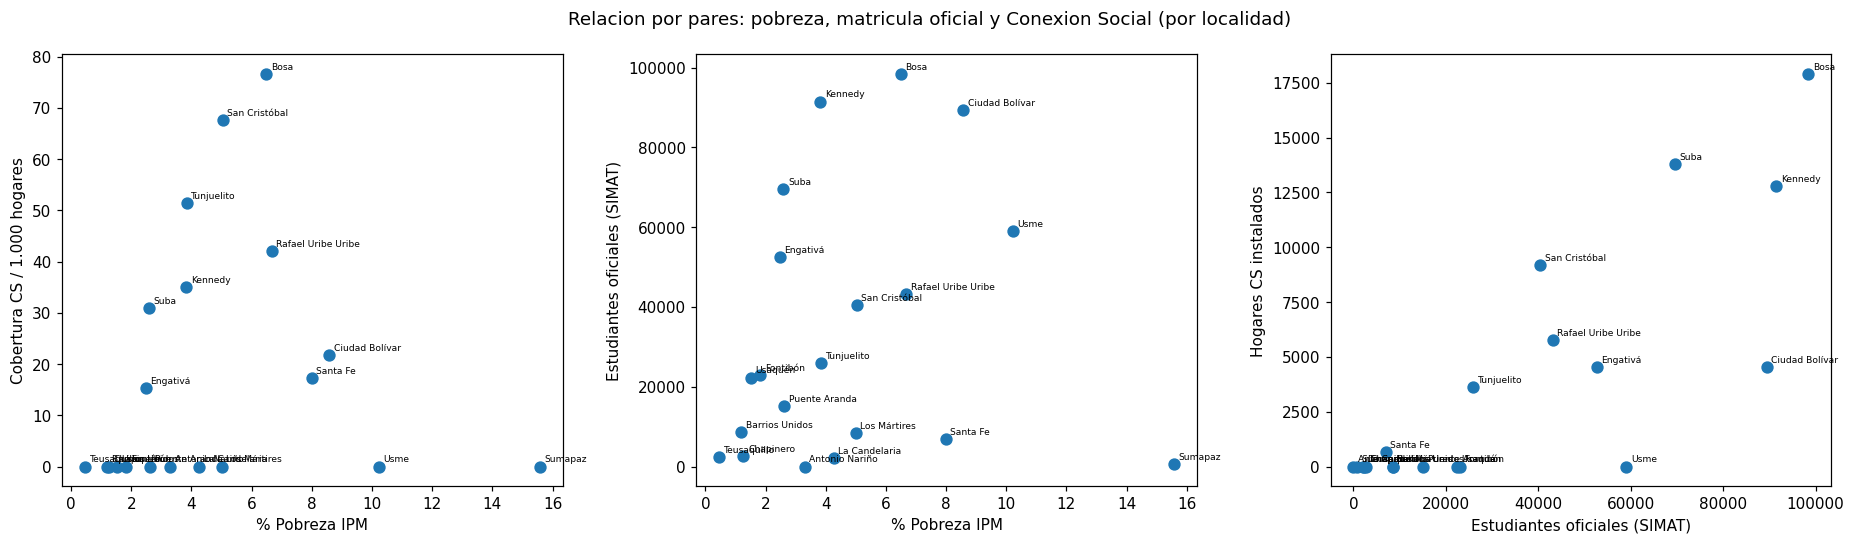

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pares = [
    ("pct_pobreza_ipm", "cobertura_cs_por_1000_hogares", "% Pobreza IPM", "Cobertura CS / 1.000 hogares"),
    ("pct_pobreza_ipm", "estudiantes_oficiales", "% Pobreza IPM", "Estudiantes oficiales (SIMAT)"),
    ("estudiantes_oficiales", "hogares_cs", "Estudiantes oficiales (SIMAT)", "Hogares CS instalados"),
]
for ax, (x, y, xlabel, ylabel) in zip(axes, pares):
    ax.scatter(comparacion_localidad[x], comparacion_localidad[y], s=50)
    for _, row in comparacion_localidad.iterrows():
        ax.annotate(row["NOMBRE_LOCALIDAD"], (row[x], row[y]), fontsize=6,
                     xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig.suptitle("Relacion por pares: pobreza, matricula oficial y Conexion Social (por localidad)")
fig.tight_layout()
fig.savefig(OUT_FIGS / "dispersion_comparacion_ipm_cs_simat.png", dpi=150)
plt.show()


## 10. Base de datos agregada para Power BI

Se arma una pequeña "base de datos" (6 tablas, todas agregadas por geografia -
**ningun hogar ni estudiante individual**) lista para conectar en Power BI Desktop, en
dos formatos:

- `outputs/powerbi/bd_conexion_social_powerbi.xlsx` - un libro de Excel con una hoja
  por tabla. Es la forma mas simple: en Power BI, *Obtener datos* > *Excel* > seleccionar
  el archivo > marcar las 6 hojas.
- `outputs/powerbi/bd_conexion_social_powerbi.db` - la misma informacion en SQLite. En
  Power BI: *Obtener datos* > *Base de datos SQLite* (requiere el driver ODBC de
  SQLite instalado una sola vez; si no lo tienes, usa el Excel).

### Tablas

| Tabla | Contenido | Grano |
|---|---|---|
| `dim_localidad` | % IPM, hogares CS, cobertura, estudiantes SIMAT | 1 fila por localidad |
| `dim_upz` | Igual que la anterior, a nivel de grupo de UPZ | 1 fila por grupo UPZ |
| `dim_sector_catastral` | Hogares CS instalados | 1 fila por sector catastral |
| `dim_establecimiento_simat` | Estudiantes matriculados (SIMAT) | 1 fila por colegio oficial |
| `hogares_cs_por_estrato` | Conteo de hogares CS | 1 fila por localidad x estrato |
| `hogares_cs_por_clasificacion_sisben` | Conteo de hogares CS | 1 fila por localidad x clasificacion Sisben |


In [34]:
import sqlite3

POWERBI_DIR = BASE_DIR / "outputs" / "powerbi"
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

dim_localidad = comparacion_localidad.drop(columns="LOC_KEY").rename(columns={"NOMBRE_LOCALIDAD": "localidad"})
dim_upz = comparacion_upz.rename(columns={"NOMBRE_UPZ_GRUPO": "upz_grupo"})
dim_sector_catastral = cs_sector.rename(columns={"SCaNombre": "sector_catastral"})
dim_establecimiento_simat = estudiantes_colegio.rename(columns={
    "dane12_ee": "codigo_dane", "nom_establecimiento_educativo": "colegio", "nom_localidad": "localidad",
})

hogares_cs_por_estrato = (
    df_cs.groupby(["Localidad", "TIP_ESTRATO_ENERGIA"]).size().rename("hogares_cs").reset_index()
    .rename(columns={"Localidad": "localidad", "TIP_ESTRATO_ENERGIA": "estrato"})
)
hogares_cs_por_clasificacion_sisben = (
    df_cs.groupby(["Localidad", "CLASIFICACION_SISBEN"]).size().rename("hogares_cs").reset_index()
    .rename(columns={"Localidad": "localidad", "CLASIFICACION_SISBEN": "clasificacion_sisben"})
)

tablas_powerbi = {
    "dim_localidad": dim_localidad,
    "dim_upz": dim_upz,
    "dim_sector_catastral": dim_sector_catastral,
    "dim_establecimiento_simat": dim_establecimiento_simat,
    "hogares_cs_por_estrato": hogares_cs_por_estrato,
    "hogares_cs_por_clasificacion_sisben": hogares_cs_por_clasificacion_sisben,
}

with pd.ExcelWriter(POWERBI_DIR / "bd_conexion_social_powerbi.xlsx", engine="openpyxl") as writer:
    for nombre, tabla in tablas_powerbi.items():
        tabla.to_excel(writer, sheet_name=nombre[:31], index=False)

db_path = POWERBI_DIR / "bd_conexion_social_powerbi.db"
db_path.unlink(missing_ok=True)
with sqlite3.connect(db_path) as con:
    for nombre, tabla in tablas_powerbi.items():
        tabla.to_sql(nombre, con, index=False)

for nombre, tabla in tablas_powerbi.items():
    print(f"{nombre}: {tabla.shape[0]} filas x {tabla.shape[1]} columnas")


dim_localidad: 20 filas x 7 columnas
dim_upz: 95 filas x 7 columnas
dim_sector_catastral: 418 filas x 2 columnas
dim_establecimiento_simat: 412 filas x 4 columnas
hogares_cs_por_estrato: 22 filas x 3 columnas
hogares_cs_por_clasificacion_sisben: 189 filas x 3 columnas


### 10.1 Ejemplo de tablero sugerido (para armar en Power BI Desktop)

Este notebook prepara los **datos**; el archivo `.pbix` en si se arma en Power BI
Desktop (formato propietario que no se puede generar por codigo). Estructura sugerida
para un tablero de una pagina:

1. **Tarjetas KPI arriba:** total hogares instalados (`SUM(dim_localidad[hogares_cs])`),
   meta del programa (100.000, dato fijo del formulario), total estudiantes oficiales
   (`SUM(dim_localidad[estudiantes_oficiales])`), % de avance.
2. **Mapa central:** visual *Mapa de formas* (Shape Map) o *ArcGIS Maps for Power BI*
   usando `data/geo/localidad.geojson` como capa de referencia, coloreado por
   `dim_localidad[pct_pobreza_ipm]`. Alternativa mas simple sin geojson: visual
   *Mapa* (burbujas) con el campo `localidad` (Power BI geocodifica el nombre) y
   tamaño de burbuja = `hogares_cs`.
3. **Barras a la derecha:** `dim_localidad` ordenado por `cobertura_cs_por_1000_hogares`
   y por `cobertura_cs_por_1000_estudiantes`, para ver que localidades tienen alta
   pobreza / mucha matricula oficial y baja cobertura (el hallazgo de las secciones 6 y 9).
4. **Filtro/segmentador:** por `localidad`, que afecte el mapa y las tablas de
   `hogares_cs_por_estrato`, `hogares_cs_por_clasificacion_sisben` y
   `dim_establecimiento_simat` (los colegios de esa localidad y sus estudiantes).
5. **Relaciones del modelo:** en la vista de *Modelado* de Power BI, relaciona
   `dim_localidad[localidad]` con `hogares_cs_por_estrato[localidad]`,
   `hogares_cs_por_clasificacion_sisben[localidad]` y
   `dim_establecimiento_simat[localidad]` (cardinalidad 1 a muchos).


## 11. Resumen de resultados exportados

Todos los resultados **agregados** (sin datos individuales, salvo los mapas de la
seccion 6.3 que se documentan aparte) quedan en:

- `outputs/tables/cruce_localidad_pobreza_conexion_social.csv`
- `outputs/tables/cruce_upz_pobreza_conexion_social.csv`
- `outputs/tables/hogares_cs_por_sector_catastral.csv`
- `outputs/tables/estudiantes_simat_por_establecimiento.csv`
- `outputs/tables/comparacion_ipm_cs_simat_localidad.csv`
- `outputs/tables/comparacion_ipm_cs_simat_upz.csv`
- `outputs/figures/dispersion_pobreza_vs_cobertura_localidad.png`
- `outputs/figures/mapa_pobreza_vs_cobertura_localidad.png` y `..._upz.png`
- `outputs/figures/mapa_ipm_con_hogares_cs.png` y `..._upz.png` (contienen coordenadas exactas de hogares, ver nota 6.3)
- `outputs/figures/mapa_hogares_cs_sector_catastral.png`
- `outputs/figures/mapa_estudiantes_simat_localidad.png` y `..._upz.png`
- `outputs/figures/mapa_simat_con_hogares_cs.png` y `..._upz.png` (contienen coordenadas exactas de hogares, ver nota 6.3)
- `outputs/figures/matriz_correlacion_ipm_cs_simat.png`
- `outputs/figures/mapas_comparacion_ipm_cs_simat.png` y `..._upz.png`
- `outputs/figures/dispersion_comparacion_ipm_cs_simat.png`
- `outputs/powerbi/bd_conexion_social_powerbi.xlsx` y `.db` (base de datos para Power BI)
- `data/geo/*.geojson` (limites publicos de localidad, UPZ y sector catastral)

Los microdatos originales (`Perfiles_CS.xlsx`, `em2021.csv`,
`20240430_variables_adicionales_2021.csv`, `Simat_1Jul26.csv`) permanecen solo en
este computador, igual que `revision_equipo_hogares_localidad.xlsx` (seccion 3.1),
que tampoco se sube a GitHub.


In [35]:
resumen = pd.DataFrame({
    "archivo": [
        "cruce_localidad_pobreza_conexion_social.csv",
        "cruce_upz_pobreza_conexion_social.csv",
        "hogares_cs_por_sector_catastral.csv",
        "estudiantes_simat_por_establecimiento.csv",
        "comparacion_ipm_cs_simat_localidad.csv",
        "bd_conexion_social_powerbi.xlsx (6 hojas)",
    ],
    "filas": [
        len(cruce_localidad), len(cruce_upz), len(cs_sector), len(estudiantes_colegio),
        len(comparacion_localidad), sum(len(t) for t in tablas_powerbi.values()),
    ],
})
resumen


,archivo,filas
0,cruce_localidad_pobreza_conexion_social.csv,20
1,cruce_upz_pobreza_conexion_social.csv,95
2,hogares_cs_por_sector_catastral.csv,418
3,estudiantes_simat_por_establecimiento.csv,412
4,comparacion_ipm_cs_simat_localidad.csv,20
5,bd_conexion_social_powerbi.xlsx (6 hojas),1156
